<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-family: 'Georgia', serif; font-size: 2.2em; margin-bottom: 10px; text-align:center">A Matemática do Movimento Browniano</h1>
  <h2 style="color: #a8dadc; font-family: 'Georgia', serif; font-size: 1.3em; font-weight: normal; text-align:center">Conceitos Teóricos e Abordagem Computacional da Equação de Langevin</h2>
  <hr style="border: 1px solid #e94560; margin: 20px 0;">
  <p style="color: #ccc; text-align:center; font-size: 1em;">Giovani Nagano &bull; Mateus Mendes &bull; Matheus Nascimento &bull; Vinicius Wasques</p>
  <p style="color: #999; text-align:center; font-size: 0.9em;">ILUM – Escola de Ciência | CNPEM </p>
</div>

## Sumário

| # | Seção | Conteúdo |
|---|-------|----------|
| 1 | [Fundamentação Teórica](#teoria) | Equação de Langevin, Processo de Wiener, Cálculo de Itô, Euler–Maruyama, Processo OU |
| 2 | [Configuração & Importações](#setup) | Parâmetros globais, estilo de plotagem, utilitários |
| 3 | [Processo de Wiener](#wiener) | Simulação em 1D, 2D e 3D; distribuições analíticas |
| 4 | [Equação de Langevin – Solução Numérica](#langevin) | Integração Euler–Maruyama, visualização da trajetória |
| 5 | [Processo de Ornstein–Uhlenbeck](#ou) | Solução analítica vs. numérica, convergência forte e fraca |
| 6 | [Análises Avançadas](#avancado) | Difusividade, VACF, Teorema de Flutuação-Dissipação, Espaço de Fase |
| 7 | [Aplicação: Difusão Livre vs. Potencial Harmônico](#potencial) | Comparação e campo de força externo |
| 8 | [Referências](#refs) | Referências Bibliográficas |

<a id='teoria'></a>

---
# 1. Fundamentação Teórica

Esta seção serve como guia de leitura para o que será implementado computacionalmente. Os conceitos apresentados aqui são desenvolvidos progressivamente ao longo do *Jupyter Notebook*.

## 1.1 Contexto Histórico

O **Movimento Browniano** foi observado em 1827 pelo botânico Robert Brown ao notar o movimento errático de grãos de pólen suspensos em água. Em 1905, **Albert Einstein** forneceu a primeira explicação teórica satisfatória, conectando o movimento microscópico das moléculas do solvente a um coeficiente de difusão macroscópico. Em 1908, **Paul Langevin** propôs uma abordagem dinâmica alternativa: em vez de raciocinar sobre distribuições de probabilidade, ele escreveu diretamente uma equação de movimento para a partícula.

## 1.2 A Equação de Langevin

Para uma partícula de massa $m$ imersa em um fluido viscoso, Langevin escreveu:

$$\boxed{m\dfrac{dv}{dt} = -\gamma v + \sigma\xi(t)}$$

onde:
- $v(t)$ é a velocidade da partícula,
- $-\gamma v$ é a **força de arrasto viscoso** (determinística, proporcional à velocidade),
- $\sigma\xi(t)$ é a **força estocástica** modelando os choques aleatórios das moléculas do solvente,
- $\xi(t)$ é o **ruído branco**, formalmente definido como $\xi(t) = dW_t/dt$.

Na forma diferencial estocástica rigorosa (Equação Diferencial Estocástica – EDE):

$$dv(t) = -\dfrac{\gamma}{m}\,v(t)\,dt + \dfrac{\sigma}{m}\,dW_t$$

Esta é uma **EDE linear com coeficientes constantes** — o mais simples dos processos de Ornstein–Uhlenbeck.

## 1.3 O Processo de Wiener

O **Processo de Wiener** $W_t$ é o modelo matemático canônico para o Movimento Browniano. Ele satisfaz:

1. $W_0 = 0$ (quase certamente),
2. Incrementos independentes: $W_t - W_s \perp W_s - W_r$ para $r < s < t$,
3. Incrementos gaussianos: $W_t - W_s \sim \mathcal{N}(0,\; t-s)$ para $0 \le s < t$,
4. Trajetórias contínuas, mas **não diferenciáveis** em nenhum ponto.

**Consequência importante:** A variância cresce linearmente com o tempo, $\text{Var}(W_t) = t$. Computacionalmente, simulamos incrementos discretos:

$$\Delta W_i = W_{t_{i+1}} - W_{t_i} \sim \mathcal{N}(0, \Delta t) = \sqrt{\Delta t}\; Z_i, \quad Z_i \sim \mathcal{N}(0,1)$$

**Lei de escala:** O Processo de Wiener satisfaz $W_{ct} \overset{d}{=} \sqrt{c}\,W_t$, o que implica que trajetórias brownianas exibem **invariância de escala** (autossimilaridade fractal com dimensão de Hausdorff = 2).

## 1.4 Cálculo de Itô e o Lema de Itô



Como trajetórias de Wiener não são diferenciáveis, a integral clássica de Riemann–Stieltjes é mal definida para processos estocásticos. **Kiyoshi Itô** resolveu isso avaliando a função no **extremo esquerdo** de cada subintervalo:

$$\int_0^T X_t\,dW_t = \lim_{n\to\infty} \sum_{i=1}^{n} X_{t_{i-1}}(W_{t_i} - W_{t_{i-1}})$$

Isso garante que o integrando seja **não-antecipativo** (adaptado à filtração do passado), essencial para modelar sistemas causais.

**Lema de Itô:** Para $dX_t = a\,dt + b\,dW_t$ e $f(t, X_t)$ duas vezes diferenciável:

$$\boxed{df = \left(\frac{\partial f}{\partial t} + a\frac{\partial f}{\partial x} + \frac{1}{2}b^2\frac{\partial^2 f}{\partial x^2}\right)dt + b\frac{\partial f}{\partial x}\,dW_t}$$

O **termo de correção de Itô** $\frac{1}{2}b^2\frac{\partial^2 f}{\partial x^2}$ não existe no cálculo clássico — ele emerge porque $(dW_t)^2 = dt$ (em vez de $\approx 0$, como seria para funções suaves).

## 1.5 Método de Euler–Maruyama

Partindo da Expansão de Itô–Taylor e truncando nos termos de primeira ordem, obtemos o método numérico mais simples para EDEs:

$$\boxed{Y_{n+1} = Y_n + a(Y_n)\,\Delta t + b(Y_n)\,\Delta W_n}$$

com $\Delta W_n \sim \mathcal{N}(0, \Delta t)$ independentes.

**Ordens de convergência:**
- **Forte** (*pathwise*): $\mathbb{E}[|Y_N - X_T|] = O(\Delta t^{1/2})$
- **Fraca** (distribuições): $|\mathbb{E}[g(Y_N)] - \mathbb{E}[g(X_T)]| = O(\Delta t^1)$

Para a equação de Langevin, os coeficientes são $a(v) = -(\gamma/m)v$ e $b(v) = \sigma/m$.

## 1.6 Processo de Ornstein–Uhlenbeck (OU)

O processo OU é **a solução analítica** da equação de Langevin. A EDE geral é:

$$dX_t = -\theta(X_t - \mu)\,dt + \sigma\,dW_t$$

cuja solução explícita (via fator integrante $e^{\theta t}$) é:

$$X_t = \mu + (X_0 - \mu)e^{-\theta t} + \sigma\int_0^t e^{-\theta(t-s)}\,dW_s$$

**Propriedades estatísticas:**

| Propriedade | Fórmula |
|-------------|----------|
| Média | $\mathbb{E}[X_t] = \mu + (X_0-\mu)e^{-\theta t}$ |
| Variância | $\text{Var}(X_t) = \dfrac{\sigma^2}{2\theta}(1 - e^{-2\theta t})$ |
| Distribuição estacionária | $X_\infty \sim \mathcal{N}\!\left(\mu,\, \dfrac{\sigma^2}{2\theta}\right)$ |
| Autocorrelação | $C(\tau) = \dfrac{\sigma^2}{2\theta}e^{-\theta|\tau|}$ |

**Conexão com a Langevin:** Para $v(t)$, temos $\theta = \gamma/m$, $\mu = 0$, $\sigma \to \sigma/m$.

**Teorema Flutuação–Dissipação:** O coeficiente de difusão $D$ e o atrito $\gamma$ não são independentes:

$$D = \frac{k_B T}{m\gamma} = \frac{\sigma^2}{2m\gamma^2}$$

Isso implica que o ruído e o atrito têm **origem microscópica comum** — os choques moleculares são responsáveis por ambos.

<a id='setup'></a>

---
# 2. Configuração & Importações

In [33]:
# ── Importações ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import animation, cm
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
from scipy.stats import norm, kstest
from scipy.stats import gaussian_kde
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

print("✓ Bibliotecas importadas com sucesso.")

✓ Bibliotecas importadas com sucesso.


In [ ]:
PAPER_STYLE = {
    # Fonte
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Georgia'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    # Eixos
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    # Linhas e marcadores
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    # Figura
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    # LaTeX
    'text.usetex': False,
    'mathtext.fontset': 'stix',
}
plt.rcParams.update(PAPER_STYLE)

# Paleta de cores diferenciada
COLORS = {
    'numerica': '#1f77b4',   # azul
    'analitica': '#d62728',  # vermelho
    'trajetoria': '#2ca02c', # verde
    'ensemble': '#9467bd',   # roxo
    'destaque': '#ff7f0e',   # laranja
    'cinza': '#7f7f7f',
}

print("✓ Estilo paper-like configurado.")

✓ Estilo paper-like configurado.


In [ ]:
# ── Parâmetros físicos globais ───────────────────────────────────────────────
# Estes parâmetros são usados ao longo de todo o notebook.
# Altere aqui para explorar diferentes regimes físicos.

# Parâmetros da partícula browniana
m     = 1.0    # Massa [u.a.]
gamma = 1.0    # Coeficiente de atrito viscoso [u.a.]
sigma = 1.0    # Amplitude do ruído estocástico [u.a.]

# Parâmetros derivados do processo OU
theta     = gamma / m                        # Taxa de retorno ao equilíbrio (θ = γ/m)
mu_ou     = 0.0                              # Valor médio assintótico (velocidade média = 0)
sigma_ou  = sigma / m                        # Intensidade do ruído no processo OU
sigma_eq  = np.sqrt(sigma**2 / (2*gamma*m))  # Desvio padrão da distribuição estacionária
D_diff    = sigma**2 / (2 * m**2 * gamma)    # Coeficiente de difusão (Einstein)
tau_c     = m / gamma                        # Tempo de correlação (tempo de Langevin)

# Semente para reprodutibilidade
SEED = 88
rng  = np.random.default_rng(SEED)

print(f"Parâmetros físicos:")
print(f"  m = {m}, γ = {gamma}, σ = {sigma}")
print(f"  θ = γ/m = {theta:.4f}")
print(f"  σ_eq = √(σ²/2γm) = {sigma_eq:.4f}   [desvio padrão estacionário de v]")
print(f"  D = σ²/(2m²γ) = {D_diff:.4f}         [coeficiente de difusão Einstein]")
print(f"  τ_c = m/γ = {tau_c:.4f}               [tempo de correlação da velocidade]")

Parâmetros físicos:
  m = 1.0, γ = 1.0, σ = 1.0
  θ = γ/m = 1.0000
  σ_eq = √(σ²/2γm) = 0.7071   [desvio padrão estacionário de v]
  D = σ²/(2m²γ) = 0.5000         [coeficiente de difusão Einstein]
  τ_c = m/γ = 1.0000               [tempo de correlação da velocidade]


In [36]:
# ── Funções analíticas do Processo de Ornstein–Uhlenbeck ────────────────────
# Estas são as soluções exatas com as quais compararemos os resultados numéricos.

def v_mean_theo(v0, t):
    """Média temporal da velocidade: E[v(t)] = v0 * exp(-θt)"""
    return v0 * np.exp(-theta * t)

def v_var_theo(t):
    """Variância temporal da velocidade: Var[v(t)] = σ²/(2γm) * (1 - exp(-2θt))"""
    return (sigma**2) / (2*gamma*m) * (1 - np.exp(-2*theta*t))

def Cv_theo(lag):
    """Autocorrelação da velocidade (VACF): C(τ) = σ²/(2γm) * exp(-θ|τ|)"""
    return (sigma**2)/(2*gamma*m) * np.exp(-theta*np.abs(lag))

def msd_v_theo(t, v0=0.0):
    """MSD da velocidade ao longo do tempo"""
    return (v0 - mu_ou)**2 * np.exp(-2*theta*t) + v_var_theo(t)

def msd_x_theo(t):
    """
    Deslocamento quadrático médio da posição para t >> τ_c (regime difusivo):
    MSD(t) = 2D*t  (lei de Einstein)
    Forma exata completa:
    MSD(t) = (σ²/γ²) * [t - (m/γ)(1 - exp(-γt/m))]
    """
    return (sigma**2 / gamma**2) * (t - (m/gamma)*(1 - np.exp(-gamma*t/m)))

def p_stationary(v):
    """Densidade de probabilidade estacionária: p_∞(v) = N(0, σ_eq²)"""
    return norm.pdf(v, loc=0, scale=sigma_eq)

print("✓ Funções analíticas definidas.")

✓ Funções analíticas definidas.


<a id='wiener'></a>

---
# 3. Processo de Wiener e Movimento Browniano

> **Guia:** Esta seção simula trajetórias brownianas puras — sem atrito nem ruído modulado. É o bloco de construção fundamental: entender $W_t$ é entender a fonte de aleatoriedade em toda a teoria.

O Processo de Wiener em dimensão $d$ é construído como:
$$\mathbf{W}(t) = \sum_{i=1}^{N(t)} \Delta\mathbf{W}_i, \quad \Delta\mathbf{W}_i \sim \mathcal{N}(\mathbf{0},\, \Delta t\,\mathbf{I}_d)$$

In [ ]:
# ── Funções para simulação do Processo de Wiener ─────────────────────────────

def simular_wiener(N_steps: int, dt: float = 1.0, dim: int = 1, n_traj: int = 1, rng_local=None) -> np.ndarray:
    """
    Simula n_traj trajetórias do Processo de Wiener em dimensão `dim`.

    Parâmetros
    ----------
    N_steps : int    — número de passos de tempo
    dt      : float  — tamanho do passo temporal
    dim     : int    — dimensão do espaço (1, 2 ou 3)
    n_traj  : int    — número de trajetórias independentes

    Retorna
    -------
    W : ndarray de shape (n_traj, N_steps+1, dim)
        W[:, 0, :] == 0 (condição inicial)
    """
    if rng_local is None:
        rng_local = rng
    # Incrementos gaussianos: shape (n_traj, N_steps, dim)
    dW = rng_local.normal(0.0, np.sqrt(dt), size=(n_traj, N_steps, dim))
    # Trajetória: soma cumulativa com W_0 = 0
    W = np.zeros((n_traj, N_steps + 1, dim))
    W[:, 1:, :] = np.cumsum(dW, axis=1)
    return W

print("✓ Funções do Processo de Wiener definidas.")

✓ Funções do Processo de Wiener definidas.


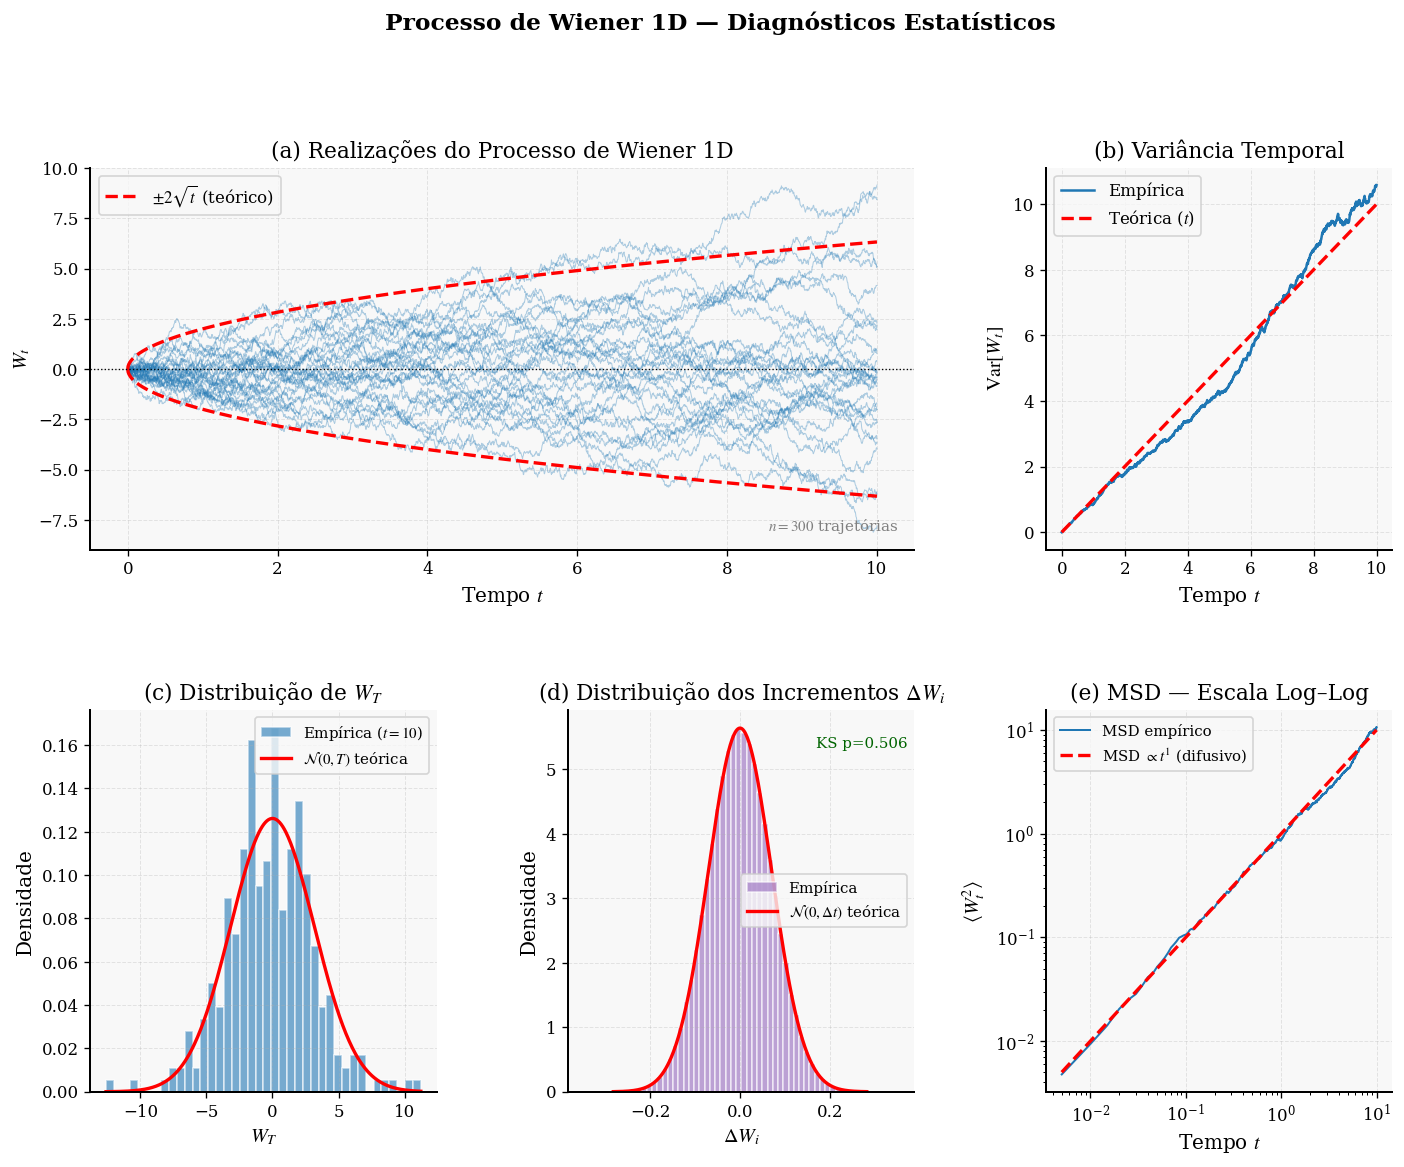

In [38]:
# ── Visualização 1D: múltiplas realizações e distribuição ────────────────────
# Demonstra a evolução da variância (Var[W_t] = t) e a normalidade dos incrementos.

N_w, dt_w = 2000, 0.005        # 2000 passos, Δt = 0.005 → T = 10
n_traj_w  = 300
t_w       = np.linspace(0, N_w*dt_w, N_w+1)

W1d = simular_wiener(N_w, dt_w, dim=1, n_traj=n_traj_w)[:, :, 0]  # shape (n_traj, N+1)

# Variância teórica
var_teo = t_w
var_num = W1d.var(axis=0)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# --- Painel A: trajetórias individuais ---
ax0 = fig.add_subplot(gs[0, :2])
for i in range(min(30, n_traj_w)):
    ax0.plot(t_w, W1d[i], lw=0.6, alpha=0.35, color=COLORS['numerica'])
ax0.plot(t_w,  2*np.sqrt(var_teo), 'r--', lw=2, label=r'$\pm 2\sqrt{t}$ (teórico)')
ax0.plot(t_w, -2*np.sqrt(var_teo), 'r--', lw=2)
ax0.axhline(0, color='k', lw=0.8, ls=':')
ax0.set_xlabel('Tempo $t$')
ax0.set_ylabel('$W_t$')
ax0.set_title('(a) Realizações do Processo de Wiener 1D')
ax0.legend(loc='upper left')
ax0.text(0.98, 0.05, f'$n = {n_traj_w}$ trajetórias', transform=ax0.transAxes,
         ha='right', fontsize=9, color='gray')

# --- Painel B: variância empírica vs. teórica ---
ax1 = fig.add_subplot(gs[0, 2])
ax1.plot(t_w, var_num, lw=1.5, color=COLORS['numerica'], label='Empírica')
ax1.plot(t_w, var_teo, 'r--', lw=2, label='Teórica ($t$)')
ax1.set_xlabel('Tempo $t$')
ax1.set_ylabel(r'$\mathrm{Var}[W_t]$')
ax1.set_title('(b) Variância Temporal')
ax1.legend()

# --- Painel C: distribuição de W_T (snapshot) ---
ax2 = fig.add_subplot(gs[1, 0])
T_snapshot = N_w * dt_w
W_T = W1d[:, -1]
ax2.hist(W_T, bins=40, density=True, alpha=0.6, color=COLORS['numerica'],
         edgecolor='white', label=f'Empírica ($t={T_snapshot:.0f}$)')
xs = np.linspace(W_T.min(), W_T.max(), 400)
ax2.plot(xs, norm.pdf(xs, 0, np.sqrt(T_snapshot)), 'r-', lw=2,
         label=r'$\mathcal{N}(0, T)$ teórica')
ax2.set_xlabel('$W_T$')
ax2.set_ylabel('Densidade')
ax2.set_title(r'(c) Distribuição de $W_T$')
ax2.legend(fontsize=9)

# --- Painel D: distribuição dos incrementos ---
ax3 = fig.add_subplot(gs[1, 1])
dW_all = np.diff(W1d, axis=1).ravel()
ax3.hist(dW_all, bins=60, density=True, alpha=0.6, color=COLORS['ensemble'],
         edgecolor='white', label='Empírica')
xs2 = np.linspace(-4*np.sqrt(dt_w), 4*np.sqrt(dt_w), 300)
ax3.plot(xs2, norm.pdf(xs2, 0, np.sqrt(dt_w)), 'r-', lw=2,
         label=r'$\mathcal{N}(0,\Delta t)$ teórica')
ax3.set_xlabel(r'$\Delta W_i$')
ax3.set_ylabel('Densidade')
ax3.set_title(r'(d) Distribuição dos Incrementos $\Delta W_i$')
ax3.legend(fontsize=9)
# Teste KS
stat, pval = kstest(dW_all, 'norm', args=(0, np.sqrt(dt_w)))
ax3.text(0.98, 0.90, f'KS p={pval:.3f}', transform=ax3.transAxes,
         ha='right', fontsize=9, color='darkgreen')

# --- Painel E: lei de escala log-log (MSD vs t) ---
ax4 = fig.add_subplot(gs[1, 2])
msd_num = np.mean(W1d**2, axis=0)
ax4.loglog(t_w[1:], msd_num[1:], lw=1.2, color=COLORS['numerica'], label='MSD empírico')
ax4.loglog(t_w[1:], t_w[1:], 'r--', lw=2, label=r'MSD $\propto t^1$ (difusivo)')
ax4.set_xlabel('Tempo $t$')
ax4.set_ylabel(r'$\langle W_t^2 \rangle$')
ax4.set_title('(e) MSD — Escala Log–Log')
ax4.legend(fontsize=9)

fig.suptitle('Processo de Wiener 1D — Diagnósticos Estatísticos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

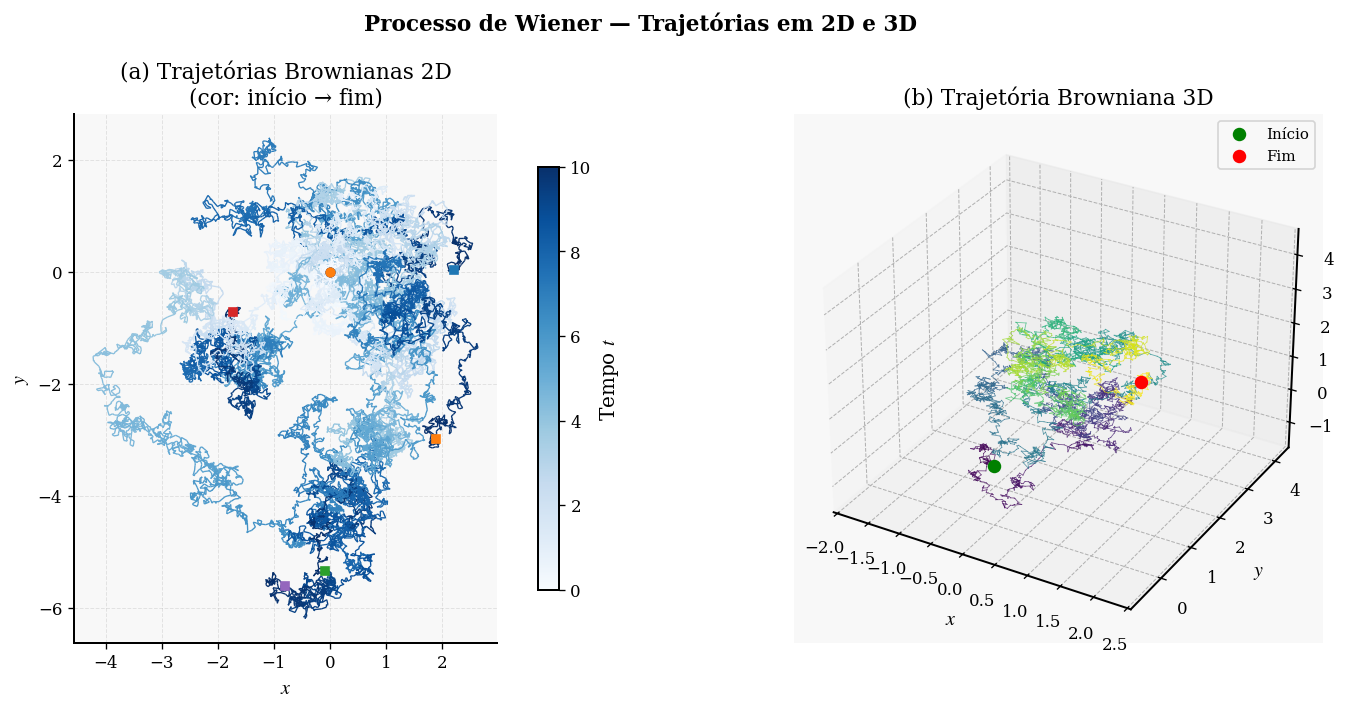

In [39]:
# ── Visualização 2D e 3D ─────────────────────────────────────────────────────
# Visualizamos trajetórias em 2D e 3D para construir intuição geométrica.
# Colorimos por tempo para mostrar a evolução temporal da trajetória.

N_vis = 5000
dt_vis = 0.002
t_vis  = np.linspace(0, N_vis*dt_vis, N_vis+1)

W2d = simular_wiener(N_vis, dt_vis, dim=2, n_traj=5)  # 5 trajetórias 2D
W3d = simular_wiener(N_vis, dt_vis, dim=3, n_traj=1)  # 1 trajetória 3D

fig = plt.figure(figsize=(14, 6))

# --- Painel A: 5 trajetórias 2D ---
ax_2d = fig.add_subplot(121)
for i, (traj, color) in enumerate(zip(W2d[:5],
          ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e'])):
    # Cor evolui com o tempo
    points = traj.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)
    from matplotlib.collections import LineCollection
    lc = LineCollection(segs, cmap='Blues', norm=Normalize(0, N_vis))
    lc.set_array(np.arange(N_vis))
    lc.set_linewidth(0.8)
    ax_2d.add_collection(lc)
    ax_2d.plot(*traj[0], 'o', color=color, ms=5, zorder=5)
    ax_2d.plot(*traj[-1], 's', color=color, ms=5, zorder=5)

ax_2d.set_aspect('equal')
ax_2d.autoscale()
ax_2d.set_xlabel('$x$')
ax_2d.set_ylabel('$y$')
ax_2d.set_title('(a) Trajetórias Brownianas 2D\n(cor: início → fim)')
sm = cm.ScalarMappable(cmap='Blues', norm=Normalize(0, N_vis*dt_vis))
sm.set_array([])
plt.colorbar(sm, ax=ax_2d, label='Tempo $t$', shrink=0.8)

# --- Painel B: 1 trajetória 3D ---
ax_3d = fig.add_subplot(122, projection='3d')
traj3 = W3d[0]  # shape (N+1, 3)
# Colorir por tempo
N3 = len(traj3)
colors_3d = cm.viridis(np.linspace(0, 1, N3-1))
for i in range(N3-1):
    ax_3d.plot(traj3[i:i+2, 0], traj3[i:i+2, 1], traj3[i:i+2, 2],
               color=colors_3d[i], lw=0.5, alpha=0.7)
ax_3d.scatter(*traj3[0], color='green', s=50, zorder=5, label='Início')
ax_3d.scatter(*traj3[-1], color='red', s=50, zorder=5, label='Fim')
ax_3d.set_xlabel('$x$')
ax_3d.set_ylabel('$y$')
ax_3d.set_zlabel('$z$')
ax_3d.set_title('(b) Trajetória Browniana 3D')
ax_3d.legend(fontsize=9)

fig.suptitle('Processo de Wiener — Trajetórias em 2D e 3D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='langevin'></a>

---
# 4. Equação de Langevin — Solução Numérica via Euler–Maruyama

> **Guia:** Aqui implementamos o **núcleo numérico** do notebook: o integrador Euler–Maruyama aplicado à equação de Langevin. Geramos tanto a velocidade $v(t)$ quanto a posição $x(t) = \int_0^t v(s)\,ds$ e inspecionamos uma trajetória individual.

O esquema iterativo para a equação de Langevin:
$$v_{n+1} = v_n - \frac{\gamma}{m}v_n\,\Delta t + \frac{\sigma}{m}\,\Delta W_n$$
$$x_{n+1} = x_n + v_n\,\Delta t$$

In [40]:
# ── Integrador Euler–Maruyama vetorizado (suporta múltiplas trajetórias) ──────

def euler_maruyama(dt: float, M: int, T: float,
                   v0: float = 0.0, x0: float = 0.0,
                   gamma_p: float = None, sigma_p: float = None, m_p: float = None,
                   dW_ext: np.ndarray = None) -> dict:
    """
    Integrador Euler–Maruyama para M trajetórias da equação de Langevin.

    Parâmetros
    ----------
    dt       : passo de tempo
    M        : número de trajetórias (ensemble)
    T        : tempo total de simulação
    v0, x0   : condições iniciais
    gamma_p, sigma_p, m_p : parâmetros (usam globais se None)
    dW_ext   : incrementos externos (para análise de erro forte pathwise)

    Retorna
    -------
    dict com chaves: 't', 'v', 'x', 'mean_v', 'var_v', 'mean_x'
    """
    g = gamma_p if gamma_p is not None else gamma
    s = sigma_p if sigma_p is not None else sigma
    mp = m_p if m_p is not None else m

    N  = int(np.round(T / dt))
    t  = np.linspace(0, T, N + 1)
    v  = np.zeros((M, N + 1));  v[:, 0]  = v0
    x  = np.zeros((M, N + 1));  x[:, 0]  = x0

    sqrt_dt = np.sqrt(dt)
    if dW_ext is None:
        dW = rng.normal(0.0, sqrt_dt, size=(M, N))
    else:
        dW = dW_ext

    # Loop explícito (claro para fins didáticos; pode ser vetorizado)
    for n in range(N):
        drift     = -(g / mp) * v[:, n]
        diffusion = (s / mp) * dW[:, n]
        v[:, n+1] = v[:, n] + drift * dt + diffusion
        x[:, n+1] = x[:, n] + v[:, n] * dt

    return {
        't':      t,
        'v':      v,
        'x':      x,
        'mean_v': v.mean(axis=0),
        'var_v':  v.var(axis=0),
        'var_x':  x.var(axis=0),
        'mean_x': x.mean(axis=0),
        'dt':     dt,
        'M':      M,
    }

print("✓ Integrador Euler–Maruyama definido.")

✓ Integrador Euler–Maruyama definido.


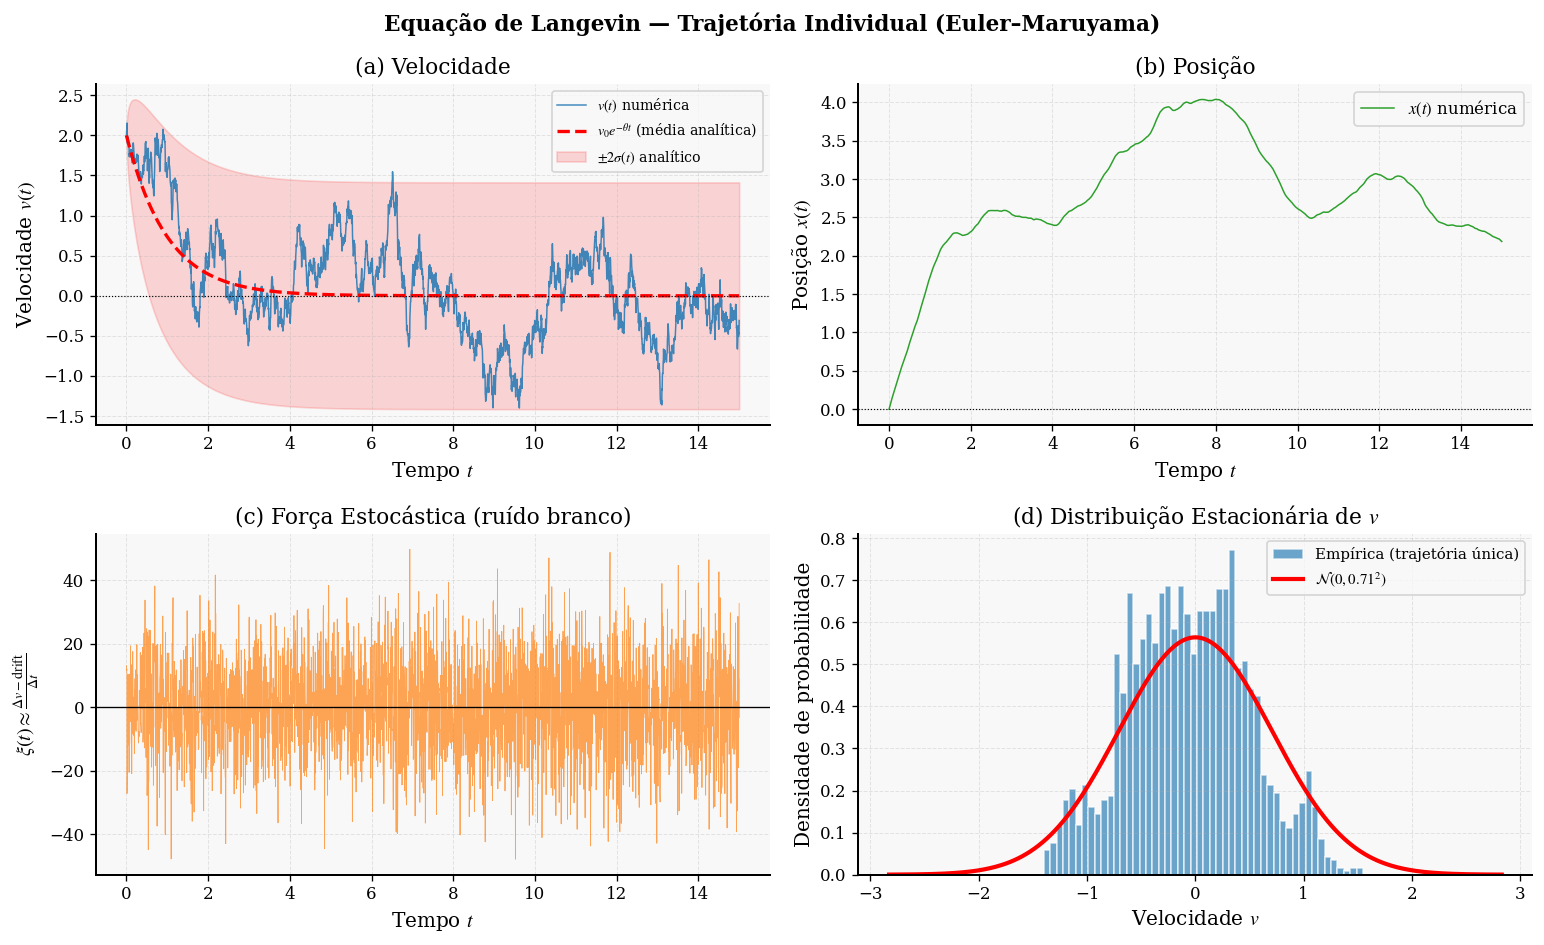

In [41]:
# ── Simulação única: inspecionando uma trajetória da equação de Langevin ──────
# Uma trajetória individual é ruidosa por natureza — isso é esperado.
# O comportamento médio (E[v(t)] → 0) só emerge no ensemble.

T_sim  = 15.0
dt_sim = 5e-3
res1   = euler_maruyama(dt_sim, M=1, T=T_sim, v0=2.0, x0=0.0)
t1, v1, x1 = res1['t'], res1['v'][0], res1['x'][0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Equação de Langevin — Trajetória Individual (Euler–Maruyama)',
             fontsize=13, fontweight='bold')

# (a) Velocidade ao longo do tempo
ax = axes[0, 0]
ax.plot(t1, v1, lw=0.9, color=COLORS['numerica'], alpha=0.85, label='$v(t)$ numérica')
ax.plot(t1, v_mean_theo(2.0, t1), 'r--', lw=2, label=r'$v_0 e^{-\theta t}$ (média analítica)')
ax.fill_between(t1,
                v_mean_theo(2.0, t1) - 2*np.sqrt(v_var_theo(t1)),
                v_mean_theo(2.0, t1) + 2*np.sqrt(v_var_theo(t1)),
                alpha=0.15, color='red', label=r'$\pm 2\sigma(t)$ analítico')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel('Velocidade $v(t)$')
ax.set_title('(a) Velocidade')
ax.legend(fontsize=8.5)

# (b) Posição ao longo do tempo
ax = axes[0, 1]
ax.plot(t1, x1, lw=0.9, color=COLORS['trajetoria'], label='$x(t)$ numérica')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel('Posição $x(t)$')
ax.set_title('(b) Posição')
ax.legend()

# (c) Força estocástica (ruído branco discreto)
ax = axes[1, 0]
# A força estocástica é dW/dt — computamos a derivada discreta de v
ruido = np.diff(v1) / dt_sim - (-(gamma/m) * v1[:-1])
ax.plot(t1[:-1], ruido, lw=0.5, color=COLORS['destaque'], alpha=0.7)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Tempo $t$')
ax.set_ylabel(r'$\xi(t) \approx \frac{\Delta v - \text{drift}}{\Delta t}$')
ax.set_title('(c) Força Estocástica (ruído branco)')

# (d) Distribuição da velocidade em regime estacionário
ax = axes[1, 1]
idx_stat = len(t1) // 3  # descarta transiente inicial
v_stat = v1[idx_stat:]
ax.hist(v_stat, bins=50, density=True, alpha=0.65, color=COLORS['numerica'],
        edgecolor='white', label='Empírica (trajetória única)')
vs = np.linspace(-4*sigma_eq, 4*sigma_eq, 300)
ax.plot(vs, p_stationary(vs), 'r-', lw=2.5, label=fr'$\mathcal{{N}}(0, {sigma_eq:.2f}^2)$')
ax.set_xlabel('Velocidade $v$')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('(d) Distribuição Estacionária de $v$')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

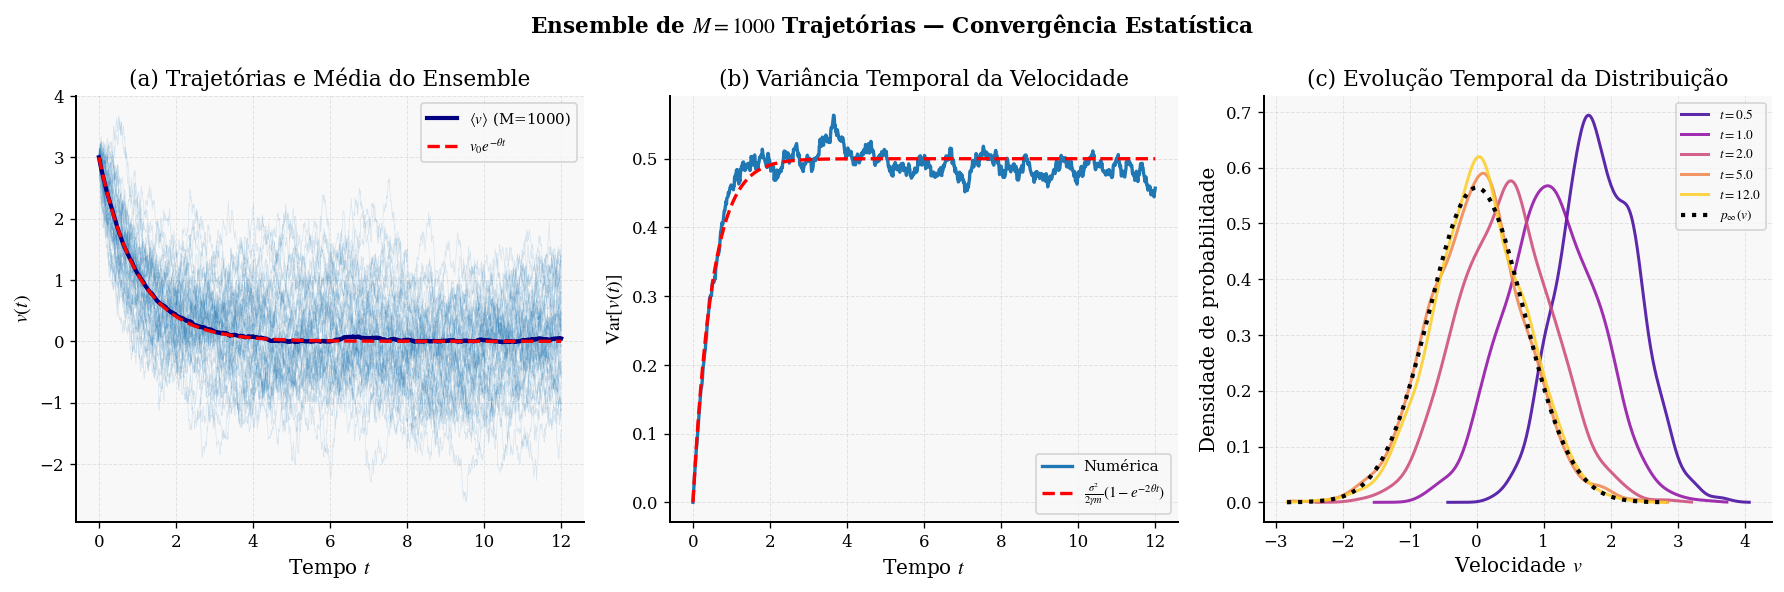

In [42]:
# ── Ensemble de trajetórias: comportamento estatístico emergente ──────────────
# Com muitas trajetórias, a média converge para a solução analítica.
# Este é o conteúdo central da teoria de processos estocásticos.

M_ens  = 1000
T_ens  = 12.0
dt_ens = 1e-2
v0_ens = 3.0

res_ens = euler_maruyama(dt_ens, M=M_ens, T=T_ens, v0=v0_ens)
t_e = res_ens['t']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Ensemble de $M = {M_ens}$ Trajetórias — Convergência Estatística',
             fontsize=13, fontweight='bold')

# (a) Trajetórias + média
ax = axes[0]
for i in range(min(50, M_ens)):
    ax.plot(t_e, res_ens['v'][i], lw=0.4, alpha=0.15, color=COLORS['numerica'])
ax.plot(t_e, res_ens['mean_v'], lw=2.5, color='navy', label=fr'$\langle v \rangle$ (M={M_ens})')
ax.plot(t_e, v_mean_theo(v0_ens, t_e), 'r--', lw=2, label=r'$v_0 e^{-\theta t}$')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel('$v(t)$')
ax.set_title('(a) Trajetórias e Média do Ensemble')
ax.legend(fontsize=9)

# (b) Variância temporal
ax = axes[1]
ax.plot(t_e, res_ens['var_v'], lw=2, color=COLORS['numerica'], label='Numérica')
ax.plot(t_e, v_var_theo(t_e),  'r--', lw=2, label=r'$\frac{\sigma^2}{2\gamma m}(1-e^{-2\theta t})$')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel(r'$\mathrm{Var}[v(t)]$')
ax.set_title('(b) Variância Temporal da Velocidade')
ax.legend(fontsize=9)

# (c) Evolução temporal da distribuição (snapshots em diferentes instantes)
ax = axes[2]
times_snap = [0.5, 1.0, 2.0, 5.0, T_ens]
palette = cm.plasma(np.linspace(0.1, 0.9, len(times_snap)))
vs_plot = np.linspace(-3*sigma_eq + v0_ens*np.exp(-theta*0), 3*sigma_eq + v0_ens, 300)
for t_snap, col in zip(times_snap, palette):
    idx = np.argmin(np.abs(t_e - t_snap))
    kde = gaussian_kde(res_ens['v'][:, idx])
    mu_t  = v_mean_theo(v0_ens, t_snap)
    std_t = np.sqrt(v_var_theo(t_snap))
    vs_t  = np.linspace(mu_t - 4*std_t, mu_t + 4*std_t, 300)
    ax.plot(vs_t, kde(vs_t), color=col, lw=1.8, alpha=0.85, label=f'$t={t_snap:.1f}$')
# Gaussiana estacionária
ax.plot(np.linspace(-4*sigma_eq, 4*sigma_eq, 300),
        p_stationary(np.linspace(-4*sigma_eq, 4*sigma_eq, 300)),
        'k-', lw=2.5, ls=':', label=r'$p_\infty(v)$')
ax.set_xlabel('Velocidade $v$')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('(c) Evolução Temporal da Distribuição')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

<a id='ou'></a>

---
# 5. Processo de Ornstein–Uhlenbeck — Analítico vs. Numérico

> **Guia:** Esta seção é o coração quantitativo do notebook. Compararemos sistematicamente a solução numérica (Euler–Maruyama) com a solução analítica exata do OU para validar o método e medir seus erros de convergência.

O OU admite também um **método de simulação exata** (sem erros de discretização):
$$Y_{n+1} = \mu + (Y_n - \mu)e^{-\theta\Delta t} + \sigma_\mathrm{OU}\sqrt{\dfrac{1 - e^{-2\theta\Delta t}}{2\theta}}\,Z_n$$

In [43]:
# ── Simulador exato do processo OU ────────────────────────────────────────────

def ou_exact(dt: float, M: int, T: float, v0: float = 0.0) -> dict:
    """
    Simulação **exata** do processo OU usando a transição condicional gaussiana.
    Não acumula erros de discretização — serve como referência de ouro.

    Fórmula: Y_{n+1} = µ + (Y_n - µ)*exp(-θΔt) + σ_OU*sqrt((1-exp(-2θΔt))/(2θ)) * Z_n
    """
    N   = int(np.round(T / dt))
    t   = np.linspace(0, T, N + 1)
    Y   = np.zeros((M, N + 1));  Y[:, 0] = v0

    alpha = np.exp(-theta * dt)
    noise_std = sigma_ou * np.sqrt((1 - np.exp(-2*theta*dt)) / (2*theta))

    Z = rng.normal(0.0, 1.0, size=(M, N))
    for n in range(N):
        Y[:, n+1] = mu_ou + (Y[:, n] - mu_ou) * alpha + noise_std * Z[:, n]

    return {'t': t, 'Y': Y, 'mean': Y.mean(axis=0), 'var': Y.var(axis=0)}

print("✓ Simulador exato OU definido.")

✓ Simulador exato OU definido.


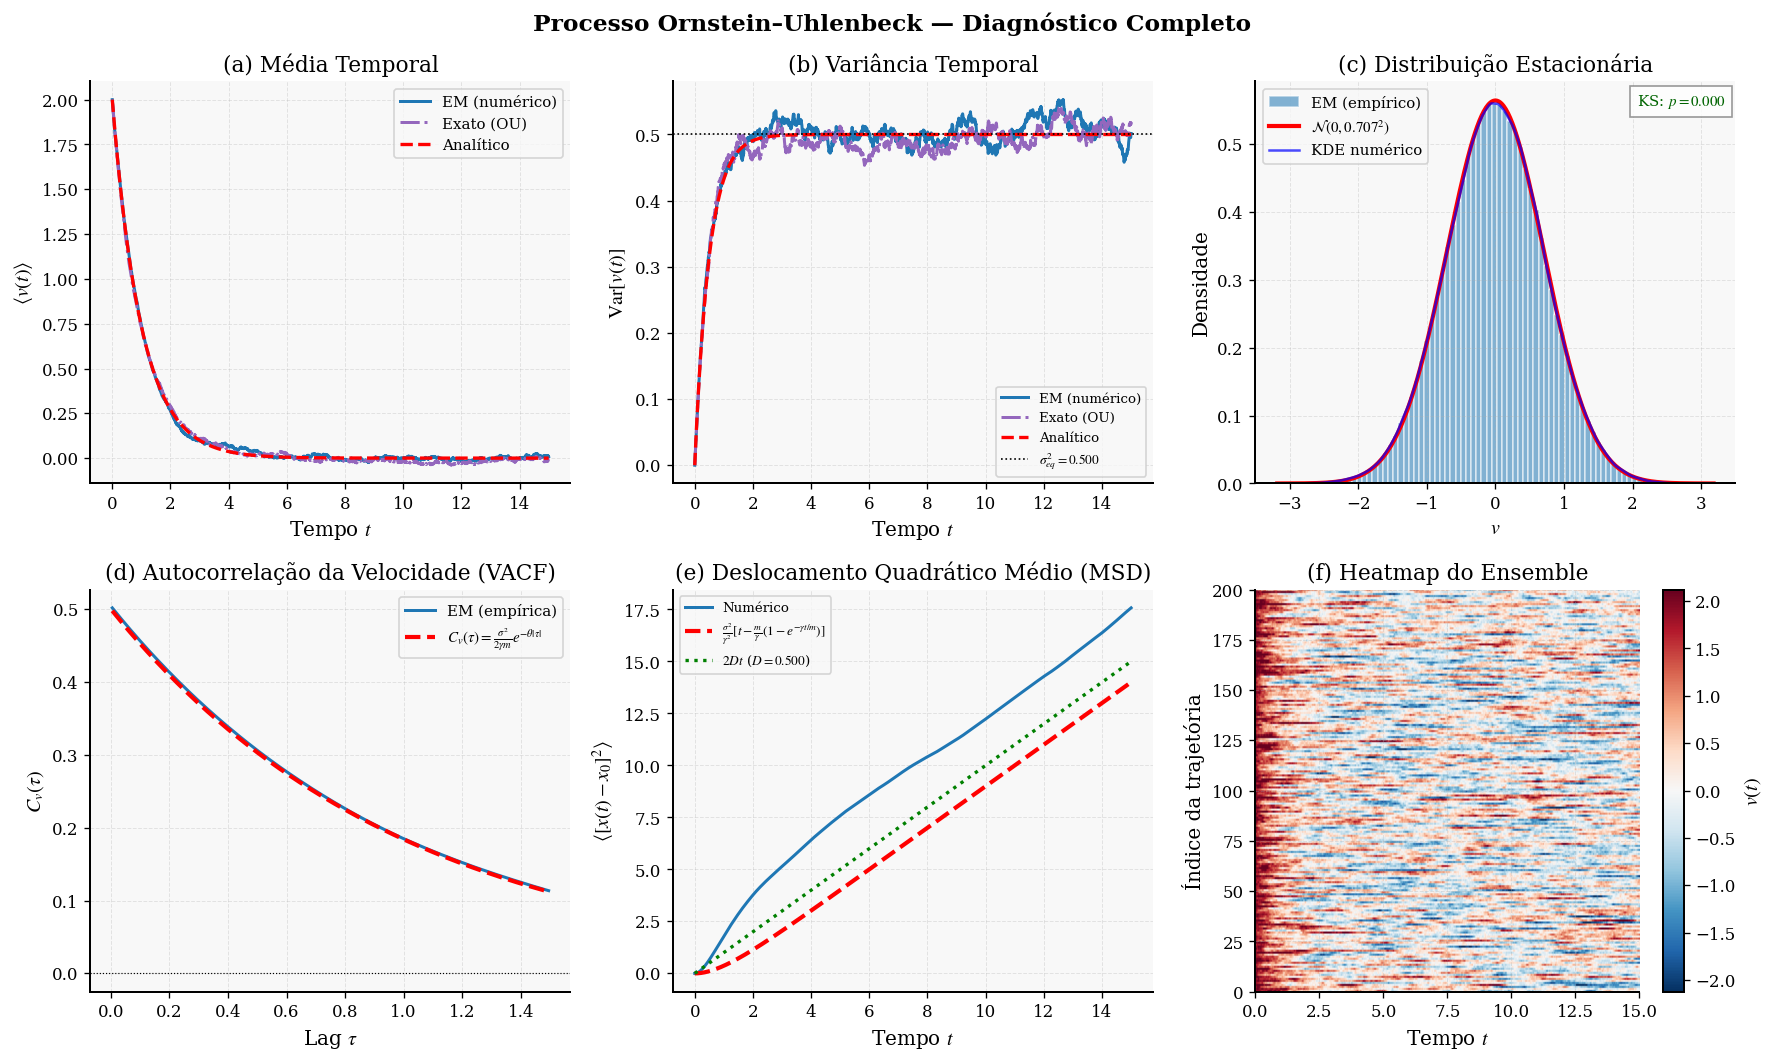

In [44]:
# ── Comparação EM vs. Solução Exata vs. Analítica ────────────────────────────

T_ou  = 15.0
dt_ou = 5e-3
M_ou  = 2000
v0_ou = 2.0

res_em  = euler_maruyama(dt_ou, M_ou, T_ou, v0=v0_ou)
res_ex  = ou_exact(dt_ou, M_ou, T_ou, v0=v0_ou)
t_ou    = res_em['t']

# Autocorrelação empírica
v_stat_em = res_em['v'][:, len(t_ou)//3:]   # descarta transiente
max_lag   = min(300, v_stat_em.shape[1]-1)
emp_acf   = np.array([(v_stat_em[:, :-lag] * v_stat_em[:, lag:]).mean()
                      for lag in range(1, max_lag)])
lag_t     = np.arange(1, max_lag) * dt_ou

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Processo Ornstein–Uhlenbeck — Diagnóstico Completo', fontsize=14, fontweight='bold')

# (a) Média temporal
ax = axes[0, 0]
ax.plot(t_ou, res_em['mean_v'], lw=1.8, color=COLORS['numerica'], label='EM (numérico)')
ax.plot(t_ou, res_ex['mean'],   lw=1.8, color=COLORS['ensemble'], ls='-.', label='Exato (OU)')
ax.plot(t_ou, v_mean_theo(v0_ou, t_ou), 'r--', lw=2, label='Analítico')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel(r'$\langle v(t) \rangle$')
ax.set_title('(a) Média Temporal')
ax.legend(fontsize=9)

# (b) Variância temporal
ax = axes[0, 1]
ax.plot(t_ou, res_em['var_v'],     lw=1.8, color=COLORS['numerica'], label='EM (numérico)')
ax.plot(t_ou, res_ex['var'],       lw=1.8, color=COLORS['ensemble'], ls='-.', label='Exato (OU)')
ax.plot(t_ou, v_var_theo(t_ou), 'r--', lw=2, label='Analítico')
ax.axhline(sigma_eq**2, color='k', lw=1, ls=':', label=fr'$\sigma_{{eq}}^2 = {sigma_eq**2:.3f}$')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel(r'$\mathrm{Var}[v(t)]$')
ax.set_title('(b) Variância Temporal')
ax.legend(fontsize=8)

# (c) Distribuição estacionária
ax = axes[0, 2]
v_all_stat = res_em['v'][:, len(t_ou)//2:].ravel()
ax.hist(v_all_stat, bins=80, density=True, alpha=0.55, color=COLORS['numerica'],
        edgecolor='white', label='EM (empírico)')
vs = np.linspace(-4.5*sigma_eq, 4.5*sigma_eq, 400)
ax.plot(vs, p_stationary(vs), 'r-', lw=2.5, label=fr'$\mathcal{{N}}(0, {sigma_eq:.3f}^2)$')
# KDE suave
kde_em = gaussian_kde(v_all_stat, bw_method='scott')
ax.plot(vs, kde_em(vs), 'b-', lw=1.5, alpha=0.7, label='KDE numérico')
ax.set_xlabel('$v$')
ax.set_ylabel('Densidade')
ax.set_title('(c) Distribuição Estacionária')
ax.legend(fontsize=9)
# Exibir resultado do teste KS
ks_stat, ks_p = kstest(v_all_stat, 'norm', args=(0, sigma_eq))
ax.text(0.98, 0.94, f'KS: $p = {ks_p:.3f}$', transform=ax.transAxes,
        ha='right', fontsize=9, color='darkgreen',
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

# (d) Autocorrelação da velocidade (VACF)
ax = axes[1, 0]
ax.plot(lag_t, emp_acf,         lw=1.8, color=COLORS['numerica'], label='EM (empírica)')
ax.plot(lag_t, Cv_theo(lag_t),  'r--',  lw=2.5, label=r'$C_v(\tau) = \frac{\sigma^2}{2\gamma m}e^{-\theta|\tau|}$')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$C_v(\tau)$')
ax.set_title('(d) Autocorrelação da Velocidade (VACF)')
ax.legend(fontsize=9)

# (e) MSD da posição
ax = axes[1, 1]
x_msd = res_em['x']  # shape (M, N+1)
msd_num = np.mean((x_msd - x_msd[:, 0:1])**2, axis=0)
ax.plot(t_ou, msd_num,           lw=1.8, color=COLORS['numerica'], label='Numérico')
ax.plot(t_ou, msd_x_theo(t_ou), 'r--',  lw=2.5, label=r'$\frac{\sigma^2}{\gamma^2}[t - \frac{m}{\gamma}(1-e^{-\gamma t/m})]$')
# Regime difusivo assintótico
ax.plot(t_ou, 2*D_diff*t_ou, 'g:', lw=2, label=f'$2Dt$ ($D={D_diff:.3f}$)')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel(r'$\langle [x(t)-x_0]^2 \rangle$')
ax.set_title('(e) Deslocamento Quadrático Médio (MSD)')
ax.legend(fontsize=8)

# (f) Heatmap do ensemble
ax = axes[1, 2]
downsample = max(1, M_ou // 200)
im = ax.imshow(res_em['v'][::downsample],
               aspect='auto', cmap='RdBu_r',
               extent=[t_ou[0], t_ou[-1], 0, min(200, M_ou)],
               vmin=-3*sigma_eq, vmax=3*sigma_eq)
plt.colorbar(im, ax=ax, label='$v(t)$')
ax.set_xlabel('Tempo $t$')
ax.set_ylabel('Índice da trajetória')
ax.set_title('(f) Heatmap do Ensemble')

plt.tight_layout()
plt.show()

## 5.1 Análise de Convergência: Erro Forte e Fraco

> **Guia:** Aqui verificamos empiricamente as ordens teóricas de convergência do método Euler–Maruyama:
> - **Erro forte** $\sim \Delta t^{1/2}$: quão bem a trajetória numérica aproxima a trajetória exata (comparação *pathwise*)
> - **Erro fraco** $\sim \Delta t^{1}$: quão bem a distribuição numérica aproxima a distribuição exata

Para o erro forte, usamos **o mesmo ruído** (incrementos de Wiener) para todas as resoluções — isso garante que estamos comparando trajetórias que evoluem sob o mesmo caminho de ruído.

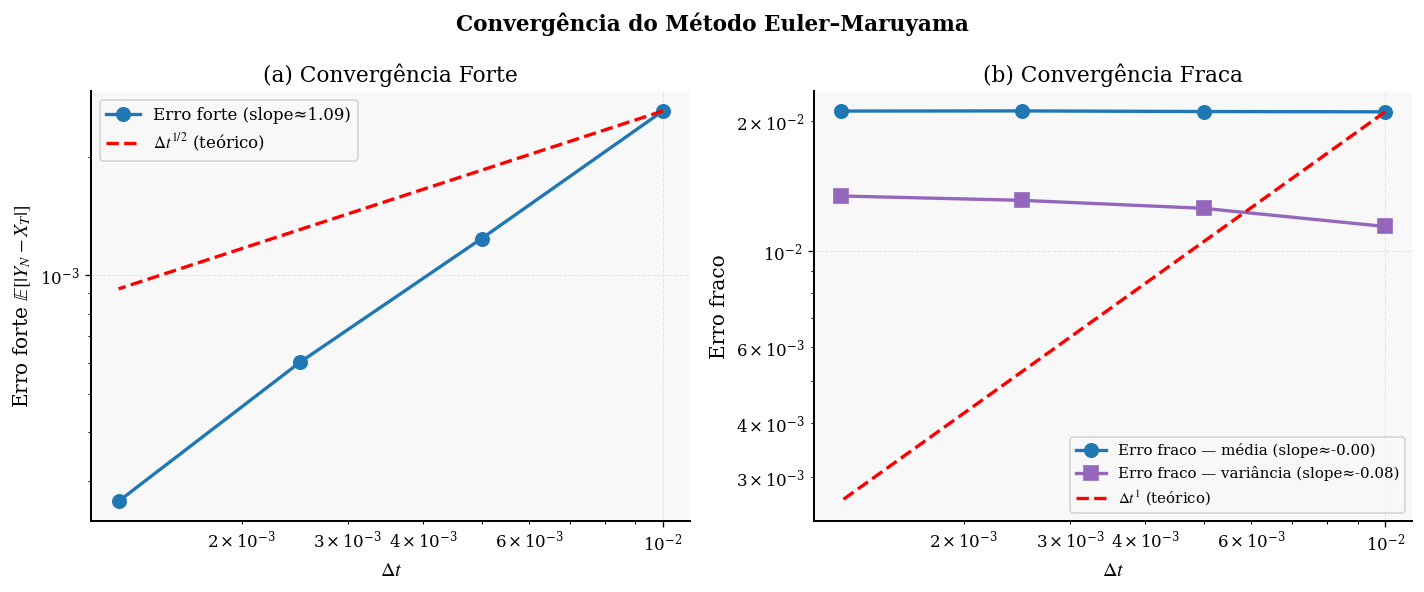

|        Δt |   Erro Forte |   Erro Fraco (média) |   Erro Fraco (var) |
|-----------|--------------|----------------------|--------------------|
| 1.000e-02 |    2.610e-03 |            2.110e-02 |          1.140e-02 |
| 5.000e-03 |    1.240e-03 |            2.110e-02 |          1.260e-02 |
| 2.500e-03 |    6.020e-04 |            2.120e-02 |          1.310e-02 |
| 1.300e-03 |    2.670e-04 |            2.110e-02 |          1.340e-02 |

Slope forte   ≈ 1.091  (esperado: 0.5)
Slope fraco   ≈ -0.002 (esperado: 1.0)


In [45]:
# ── Análise de convergência ───────────────────────────────────────────────────
# Estratégia: gerar incrementos finos e agregar para cada dt_coarse

dts_conv = [1e-2, 5e-3, 2.5e-3, 1.25e-3]
dt_fine  = dts_conv[-1] / 4   # dt de referência (muito fino)
T_conv   = 10.0
M_conv   = 500
v0_conv  = 0.0

# Gerar incrementos finos base (usados para todos os dts)
N_fine = int(np.round(T_conv / dt_fine))
dW_base = rng.normal(0.0, np.sqrt(dt_fine), size=(M_conv, N_fine))

# Solução de referência (com dt_fine)
ref = euler_maruyama(dt_fine, M_conv, T_conv, v0=v0_conv, dW_ext=dW_base)
v_ref_T = ref['v'][:, -1]   # velocidade final (para erro forte)

strong_errs = []
weak_errs_mean = []
weak_errs_var  = []

for dt_c in dts_conv:
    ratio = int(round(dt_c / dt_fine))
    N_c   = int(round(T_conv / dt_c))
    # Agregar incrementos
    dW_c = dW_base[:, :N_c*ratio].reshape(M_conv, N_c, ratio).sum(axis=2)

    res_c = euler_maruyama(dt_c, M_conv, T_conv, v0=v0_conv, dW_ext=dW_c)
    v_c_T = res_c['v'][:, -1]

    # Erro forte: E[|Y_N - X_T|]
    strong_errs.append(np.mean(np.abs(v_c_T - v_ref_T)))
    # Erro fraco: |E[Y_N] - E[X_T]|  e  |Var[Y_N] - Var[X_T]|
    v_var_exact = v_var_theo(T_conv)
    v_mean_exact = v_mean_theo(v0_conv, T_conv)
    weak_errs_mean.append(np.abs(v_c_T.mean() - v_mean_exact))
    weak_errs_var.append( np.abs(v_c_T.var()  - v_var_exact))

dts_arr  = np.array(dts_conv)
se_arr   = np.array(strong_errs)
we_m_arr = np.array(weak_errs_mean)
we_v_arr = np.array(weak_errs_var)

# Ajuste de slope
slope_s  = np.polyfit(np.log(dts_arr), np.log(se_arr + 1e-16), 1)[0]
slope_wm = np.polyfit(np.log(dts_arr), np.log(we_m_arr + 1e-16), 1)[0]
slope_wv = np.polyfit(np.log(dts_arr), np.log(we_v_arr + 1e-16), 1)[0]

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Convergência do Método Euler–Maruyama', fontsize=13, fontweight='bold')

ax = axes[0]
ax.loglog(dts_arr, se_arr, 'o-', lw=2, color=COLORS['numerica'],
          ms=8, label=f'Erro forte (slope≈{slope_s:.2f})')
ax.loglog(dts_arr, dts_arr**0.5 * se_arr[0] / dts_arr[0]**0.5, '--',
          color='red', lw=2, label=r'$\Delta t^{1/2}$ (teórico)')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel('Erro forte $\\mathbb{E}[|Y_N - X_T|]$')
ax.set_title('(a) Convergência Forte')
ax.legend()

ax = axes[1]
ax.loglog(dts_arr, we_m_arr, 'o-', lw=2, color=COLORS['numerica'],
          ms=8, label=f'Erro fraco — média (slope≈{slope_wm:.2f})')
ax.loglog(dts_arr, we_v_arr, 's-', lw=2, color=COLORS['ensemble'],
          ms=8, label=f'Erro fraco — variância (slope≈{slope_wv:.2f})')
ax.loglog(dts_arr, dts_arr * we_m_arr[0] / dts_arr[0], '--',
          color='red', lw=2, label=r'$\Delta t^1$ (teórico)')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel('Erro fraco')
ax.set_title('(b) Convergência Fraca')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Tabela resumo
tabela = [
    [f'{dt:.4f}', f'{se:.2e}', f'{wm:.2e}', f'{wv:.2e}']
    for dt, se, wm, wv in zip(dts_arr, se_arr, we_m_arr, we_v_arr)
]
print(tabulate(tabela, headers=['Δt', 'Erro Forte', 'Erro Fraco (média)', 'Erro Fraco (var)'],
               tablefmt='github', floatfmt='.3e'))
print(f'\nSlope forte   ≈ {slope_s:.3f}  (esperado: 0.5)')
print(f'Slope fraco   ≈ {slope_wm:.3f} (esperado: 1.0)')

<a id='avancado'></a>

---
# 6. Análises Avançadas

> **Guia:** Esta seção explora fenômenos mais ricos que emergem da dinâmica browniana: o coeficiente de difusão calculado via integração da VACF (Teorema de Green–Kubo), o espaço de fase estocástico, e a dependência dos observáveis com os parâmetros físicos do sistema.

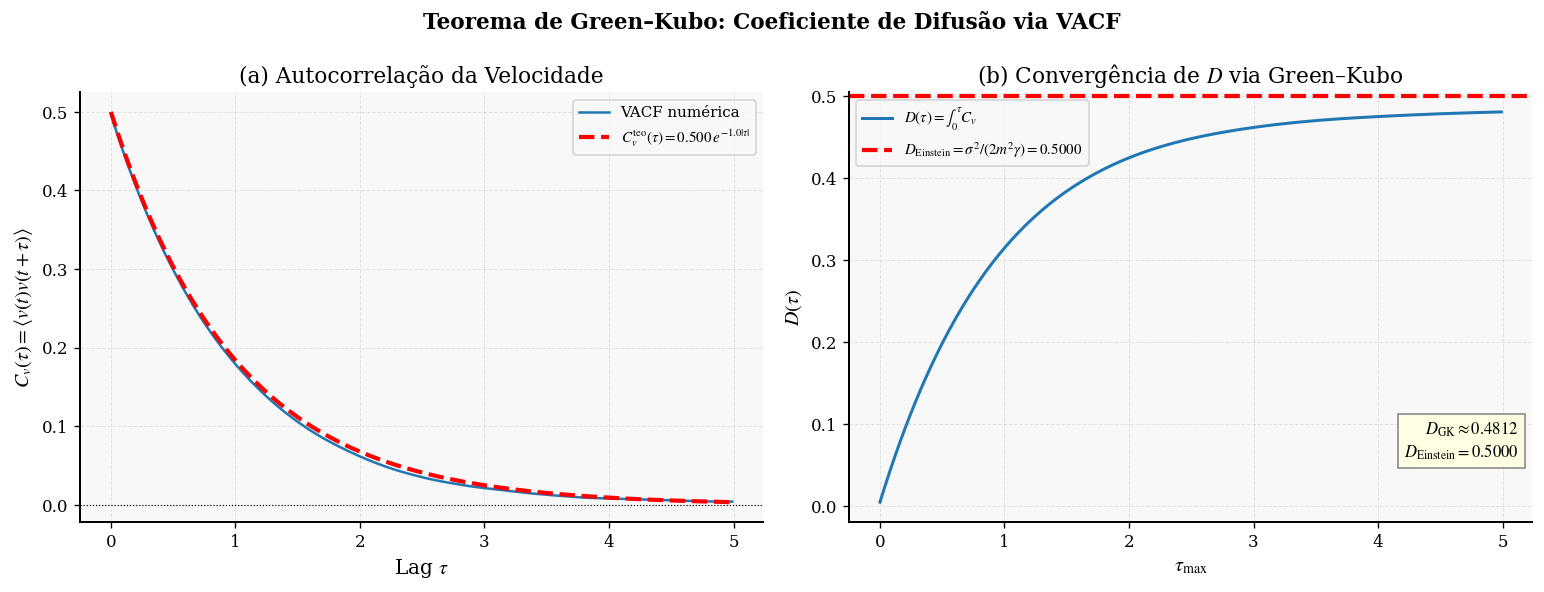

D (Green–Kubo numérico)  = 0.48116
D (Einstein, analítico)  = 0.50000
Erro relativo            = 3.77%


In [46]:
# ── Teorema de Green–Kubo: D a partir da VACF ─────────────────────────────────
# O coeficiente de difusão pode ser obtido integrando a autocorrelação da velocidade:
#
#   D = ∫_0^∞ C_v(τ) dτ = (σ²)/(2γ²m)  [Einstein–Helfand]
#
# Verificaremos que a integração numérica da VACF empírica converge para D_diff.

T_gk  = 20.0
dt_gk = 1e-2
M_gk  = 3000

res_gk = euler_maruyama(dt_gk, M_gk, T_gk, v0=0.0)

# Calcular VACF usando apenas a segunda metade (regime estacionário)
half = res_gk['v'].shape[1] // 2
v_eq = res_gk['v'][:, half:]
max_lag_gk = min(500, v_eq.shape[1] - 1)

# lag=0: C(0) = <v²> — tratado separadamente pois v_eq[:, :-0] retorna array vazio
# lag>0: C(τ) = <v(t)·v(t+τ)> via produto deslocado
acf_gk = np.empty(max_lag_gk)
acf_gk[0] = (v_eq ** 2).mean()                              # C(0) = <v²>
for lag in range(1, max_lag_gk):
    acf_gk[lag] = (v_eq[:, :-lag] * v_eq[:, lag:]).mean()   # C(τ)
lag_gk = np.arange(max_lag_gk) * dt_gk

# Integração numérica da VACF (Green–Kubo)
D_gk = np.cumsum(acf_gk) * dt_gk   # integral acumulada

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Teorema de Green–Kubo: Coeficiente de Difusão via VACF',
             fontsize=13, fontweight='bold')

# VACF
ax = axes[0]
ax.plot(lag_gk, acf_gk, lw=1.5, color=COLORS['numerica'], label='VACF numérica')
ax.plot(lag_gk, Cv_theo(lag_gk), 'r--', lw=2.5,
        label=fr'$C_v^{{\rm teo}}(\tau) = {sigma_eq**2:.3f}\,e^{{-{theta:.1f}|\tau|}}$')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$C_v(\tau) = \langle v(t)v(t+\tau)\rangle$')
ax.set_title('(a) Autocorrelação da Velocidade')
ax.legend(fontsize=9)

# D acumulado via Green–Kubo
ax = axes[1]
ax.plot(lag_gk, D_gk, lw=1.8, color=COLORS['numerica'], label='$D(\\tau) = \\int_0^\\tau C_v$')
ax.axhline(D_diff, color='r', lw=2.5, ls='--',
           label=fr'$D_{{\rm Einstein}} = \sigma^2/(2m^2\gamma) = {D_diff:.4f}$')
ax.set_xlabel(r'$\tau_\mathrm{max}$')
ax.set_ylabel('$D(\\tau)$')
ax.set_title('(b) Convergência de $D$ via Green–Kubo')
ax.legend(fontsize=9)
ax.text(0.98, 0.15, f'$D_{{\\rm GK}} \\approx {D_gk[-1]:.4f}$\n$D_{{\\rm Einstein}} = {D_diff:.4f}$',
        transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(facecolor='lightyellow', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()

print(f"D (Green–Kubo numérico)  = {D_gk[-1]:.5f}")
print(f"D (Einstein, analítico)  = {D_diff:.5f}")
print(f"Erro relativo            = {abs(D_gk[-1]-D_diff)/D_diff*100:.2f}%")

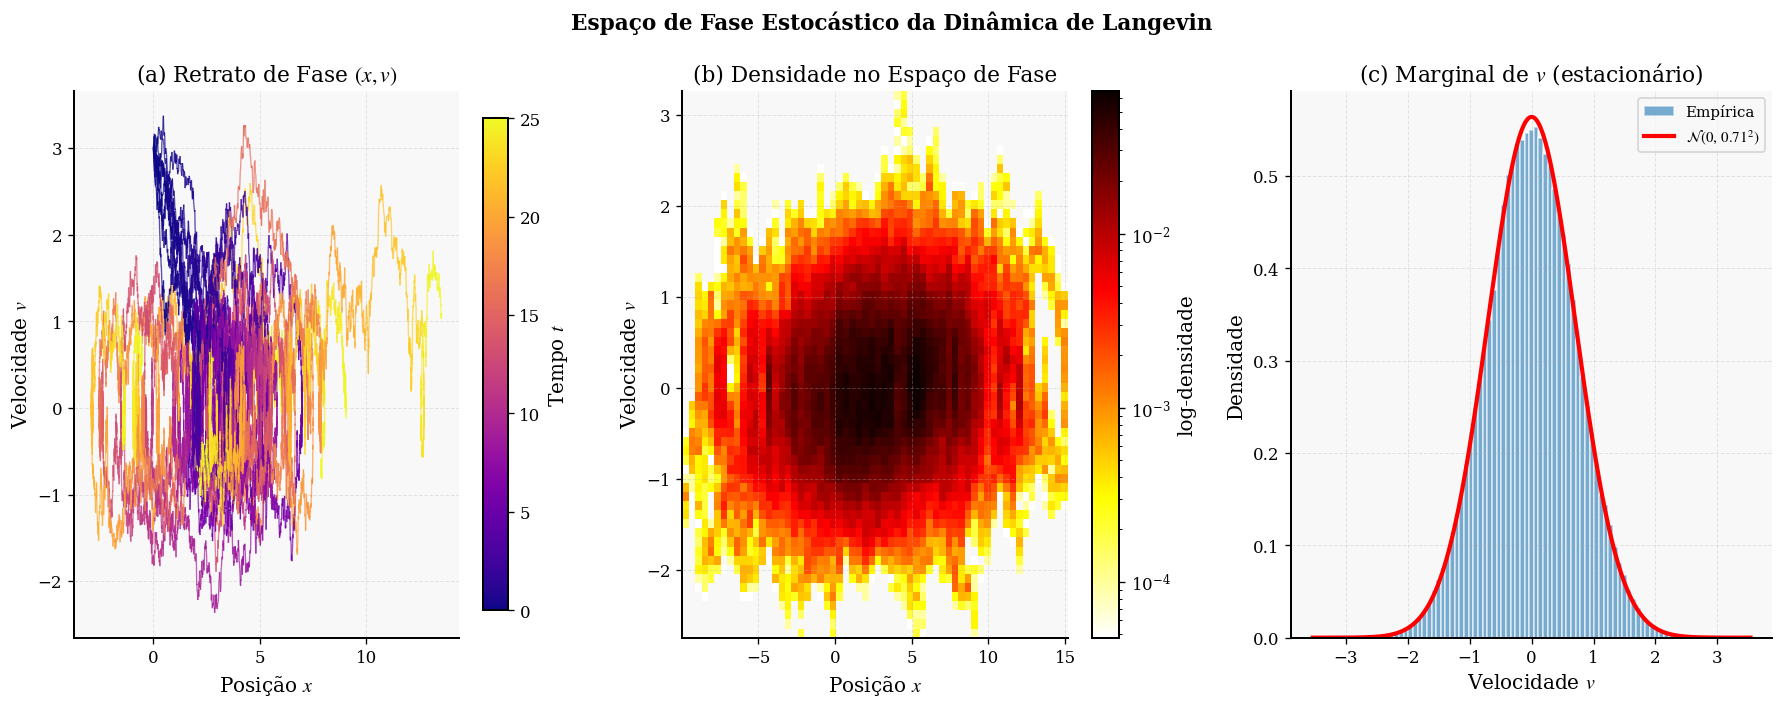

In [47]:
# ── Espaço de fase estocástico: retrato de fase (x, v) ───────────────────────
# O retrato de fase de um oscilador harmônico amortecido é uma espiral que converge
# para a origem. Com ruído, obtemos uma nuvem difusa no regime estacionário.

T_ph   = 25.0
dt_ph  = 5e-3
M_ph   = 200
v0_ph  = 3.0

res_ph = euler_maruyama(dt_ph, M_ph, T_ph, v0=v0_ph)
t_ph   = res_ph['t']
v_ph   = res_ph['v']
x_ph   = res_ph['x']

fig = plt.figure(figsize=(15, 6))

# --- Retrato de fase: trajetórias individuais coloridas por tempo ---
ax1 = fig.add_subplot(131)
n_show = 10
for i in range(n_show):
    from matplotlib.collections import LineCollection
    pts = np.stack([x_ph[i], v_ph[i]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap='plasma', norm=Normalize(0, T_ph), lw=0.8, alpha=0.7)
    lc.set_array(t_ph[:-1])
    ax1.add_collection(lc)
ax1.autoscale()
sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, T_ph))
sm.set_array([])
plt.colorbar(sm, ax=ax1, label='Tempo $t$', shrink=0.9)
ax1.set_xlabel('Posição $x$')
ax1.set_ylabel('Velocidade $v$')
ax1.set_title('(a) Retrato de Fase $(x, v)$')

# --- Densidade no espaço de fase (regime estacionário) ---
ax2 = fig.add_subplot(132)
half_ph = len(t_ph) // 2
x_stat_ph = x_ph[:, half_ph:].ravel()
v_stat_ph = v_ph[:, half_ph:].ravel()
# Normalize x e v para a escala correta
h = ax2.hist2d(x_stat_ph, v_stat_ph, bins=60, density=True,
               cmap='hot_r', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=ax2, label='log-densidade')
ax2.set_xlabel('Posição $x$')
ax2.set_ylabel('Velocidade $v$')
ax2.set_title('(b) Densidade no Espaço de Fase')

# --- Distribuição marginal de v (no estacionário) ---
ax3 = fig.add_subplot(133)
ax3.hist(v_stat_ph, bins=80, density=True, alpha=0.6, color=COLORS['numerica'],
         edgecolor='white', label='Empírica')
vs = np.linspace(-5*sigma_eq, 5*sigma_eq, 400)
ax3.plot(vs, p_stationary(vs), 'r-', lw=2.5,
         label=fr'$\mathcal{{N}}(0,\, {sigma_eq:.2f}^2)$')
ax3.set_xlabel('Velocidade $v$')
ax3.set_ylabel('Densidade')
ax3.set_title('(c) Marginal de $v$ (estacionário)')
ax3.legend(fontsize=9)

fig.suptitle('Espaço de Fase Estocástico da Dinâmica de Langevin',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

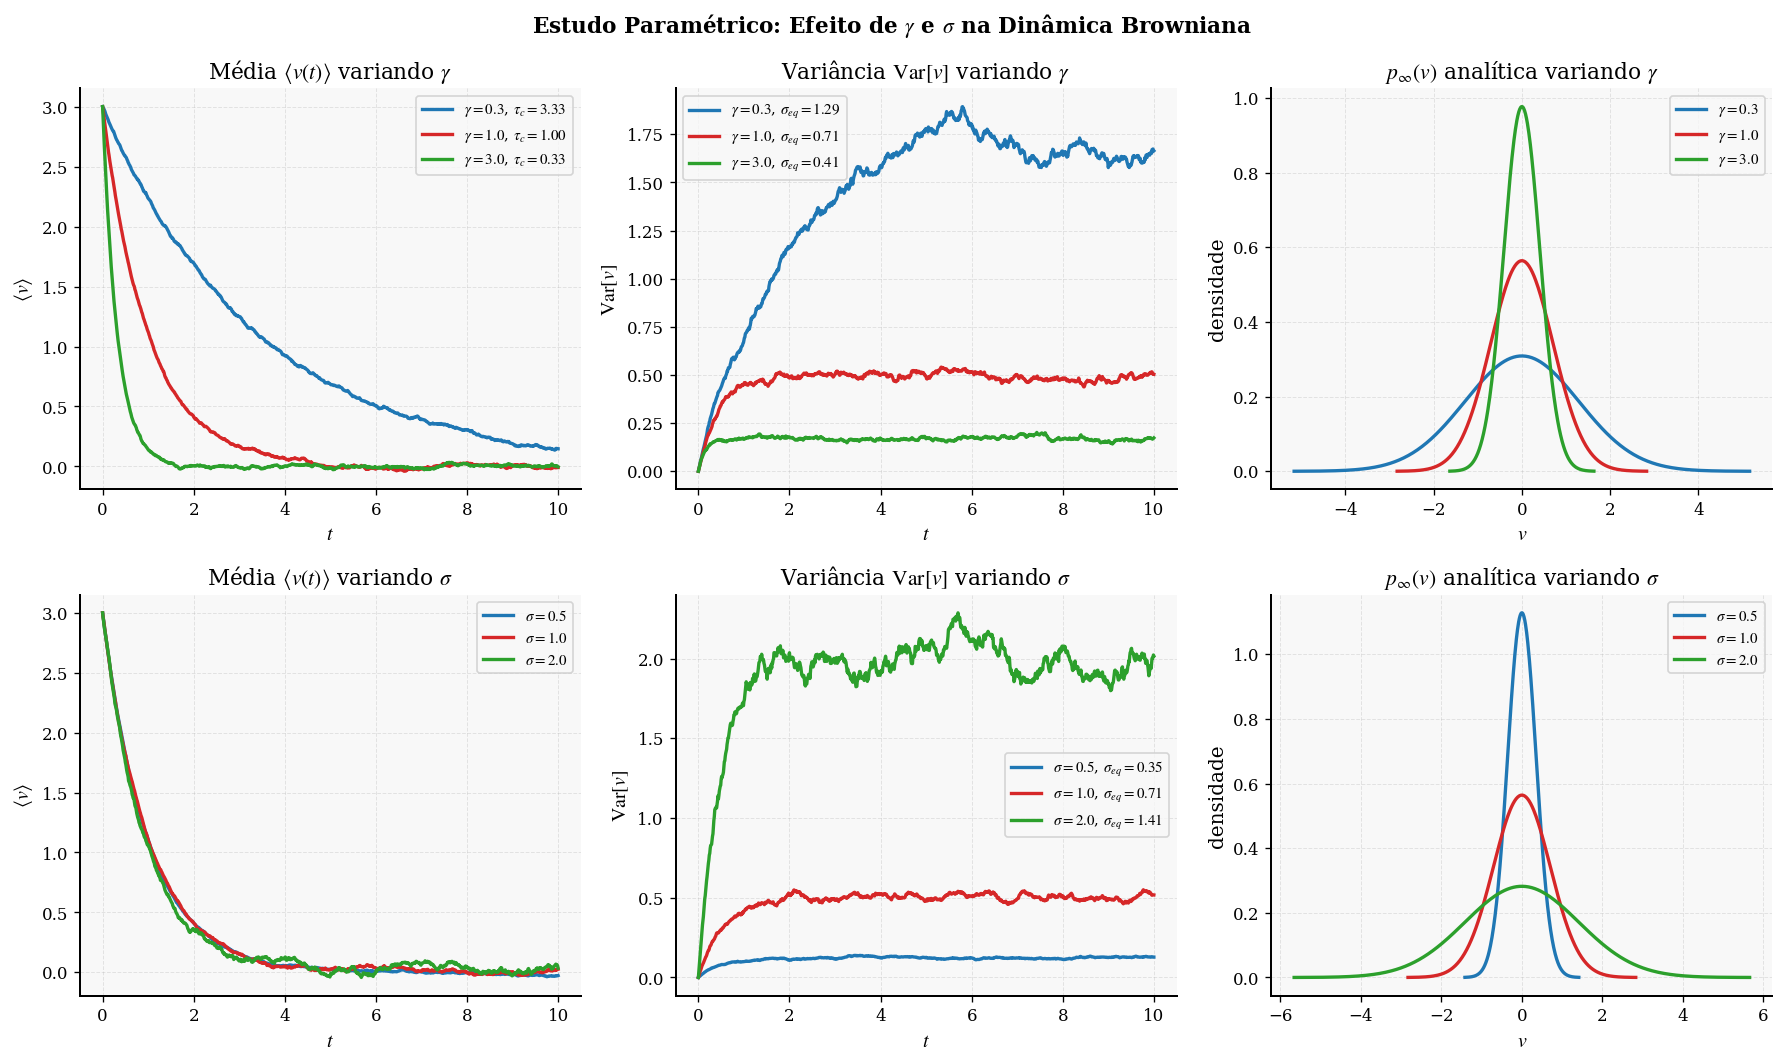

In [48]:
# ── Estudo paramétrico: efeito de γ e σ no comportamento do sistema ───────────
# Variamos o atrito (γ) e a intensidade do ruído (σ) para mostrar como cada um
# afeta o tempo de relaxação e a largura da distribuição estacionária.

T_par  = 10.0
dt_par = 1e-2
M_par  = 1000

gammas = [0.3, 1.0, 3.0]
sigmas = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Estudo Paramétrico: Efeito de $\\gamma$ e $\\sigma$ na Dinâmica Browniana',
             fontsize=13, fontweight='bold')

colors_par = ['#1f77b4', '#d62728', '#2ca02c']

# Variação de γ (σ fixo)
for j, (gam, col) in enumerate(zip(gammas, colors_par)):
    res_p = euler_maruyama(dt_par, M_par, T_par, v0=3.0,
                           gamma_p=gam, sigma_p=sigma, m_p=m)
    t_p   = res_p['t']
    theta_p  = gam / m
    sigma_eq_p = np.sqrt(sigma**2 / (2*gam*m))

    axes[0, 0].plot(t_p, res_p['mean_v'], lw=2, color=col,
                    label=fr'$\gamma={gam}$, $\tau_c={m/gam:.2f}$')
    axes[0, 1].plot(t_p, res_p['var_v'], lw=2, color=col,
                    label=fr'$\gamma={gam}$, $\sigma_{{eq}}={sigma_eq_p:.2f}$')
    vs_p = np.linspace(-4*sigma_eq_p, 4*sigma_eq_p, 300)
    axes[0, 2].plot(vs_p, norm.pdf(vs_p, 0, sigma_eq_p), lw=2, color=col,
                    label=fr'$\gamma={gam}$')

axes[0, 0].set_title(r'Média $\langle v(t) \rangle$ variando $\gamma$')
axes[0, 0].set_xlabel('$t$');  axes[0, 0].set_ylabel(r'$\langle v \rangle$'); axes[0, 0].legend(fontsize=9)
axes[0, 1].set_title(r'Variância $\mathrm{Var}[v]$ variando $\gamma$')
axes[0, 1].set_xlabel('$t$');  axes[0, 1].set_ylabel(r'$\mathrm{Var}[v]$'); axes[0, 1].legend(fontsize=9)
axes[0, 2].set_title(r'$p_\infty(v)$ analítica variando $\gamma$')
axes[0, 2].set_xlabel('$v$');  axes[0, 2].set_ylabel('densidade'); axes[0, 2].legend(fontsize=9)

# Variação de σ (γ fixo)
for j, (sig, col) in enumerate(zip(sigmas, colors_par)):
    res_p = euler_maruyama(dt_par, M_par, T_par, v0=3.0,
                           gamma_p=gamma, sigma_p=sig, m_p=m)
    t_p   = res_p['t']
    sigma_eq_p = np.sqrt(sig**2 / (2*gamma*m))

    axes[1, 0].plot(t_p, res_p['mean_v'], lw=2, color=col,
                    label=fr'$\sigma={sig}$')
    axes[1, 1].plot(t_p, res_p['var_v'], lw=2, color=col,
                    label=fr'$\sigma={sig}$, $\sigma_{{eq}}={sigma_eq_p:.2f}$')
    vs_p = np.linspace(-4*sigma_eq_p, 4*sigma_eq_p, 300)
    axes[1, 2].plot(vs_p, norm.pdf(vs_p, 0, sigma_eq_p), lw=2, color=col,
                    label=fr'$\sigma={sig}$')

axes[1, 0].set_title(r'Média $\langle v(t) \rangle$ variando $\sigma$')
axes[1, 0].set_xlabel('$t$');  axes[1, 0].set_ylabel(r'$\langle v \rangle$'); axes[1, 0].legend(fontsize=9)
axes[1, 1].set_title(r'Variância $\mathrm{Var}[v]$ variando $\sigma$')
axes[1, 1].set_xlabel('$t$');  axes[1, 1].set_ylabel(r'$\mathrm{Var}[v]$'); axes[1, 1].legend(fontsize=9)
axes[1, 2].set_title(r'$p_\infty(v)$ analítica variando $\sigma$')
axes[1, 2].set_xlabel('$v$');  axes[1, 2].set_ylabel('densidade'); axes[1, 2].legend(fontsize=9)

plt.tight_layout()
plt.show()

<a id='potencial'></a>

---
# 7. Extensão: Difusão Livre vs. Potencial Harmônico

> **Guia:** Uma extensão natural da equação de Langevin inclui um **campo de força externo** $F(x)$. Para um potencial harmônico $U(x) = \frac{1}{2}kx^2$ (força $F = -kx$), a EDE fica:
>
> $$m\frac{dv}{dt} = -\gamma v - kx + \sigma\xi(t)$$
>
> Este sistema é chamado de **oscilador harmônico estocástico** e modela partículas presas em armadilhas ópticas, moléculas vibracionais, e muito mais.

A EDE acoplada é:
$$dv = \left(-\frac{\gamma}{m}v - \frac{k}{m}x\right)dt + \frac{\sigma}{m}dW_t$$
$$dx = v\,dt$$

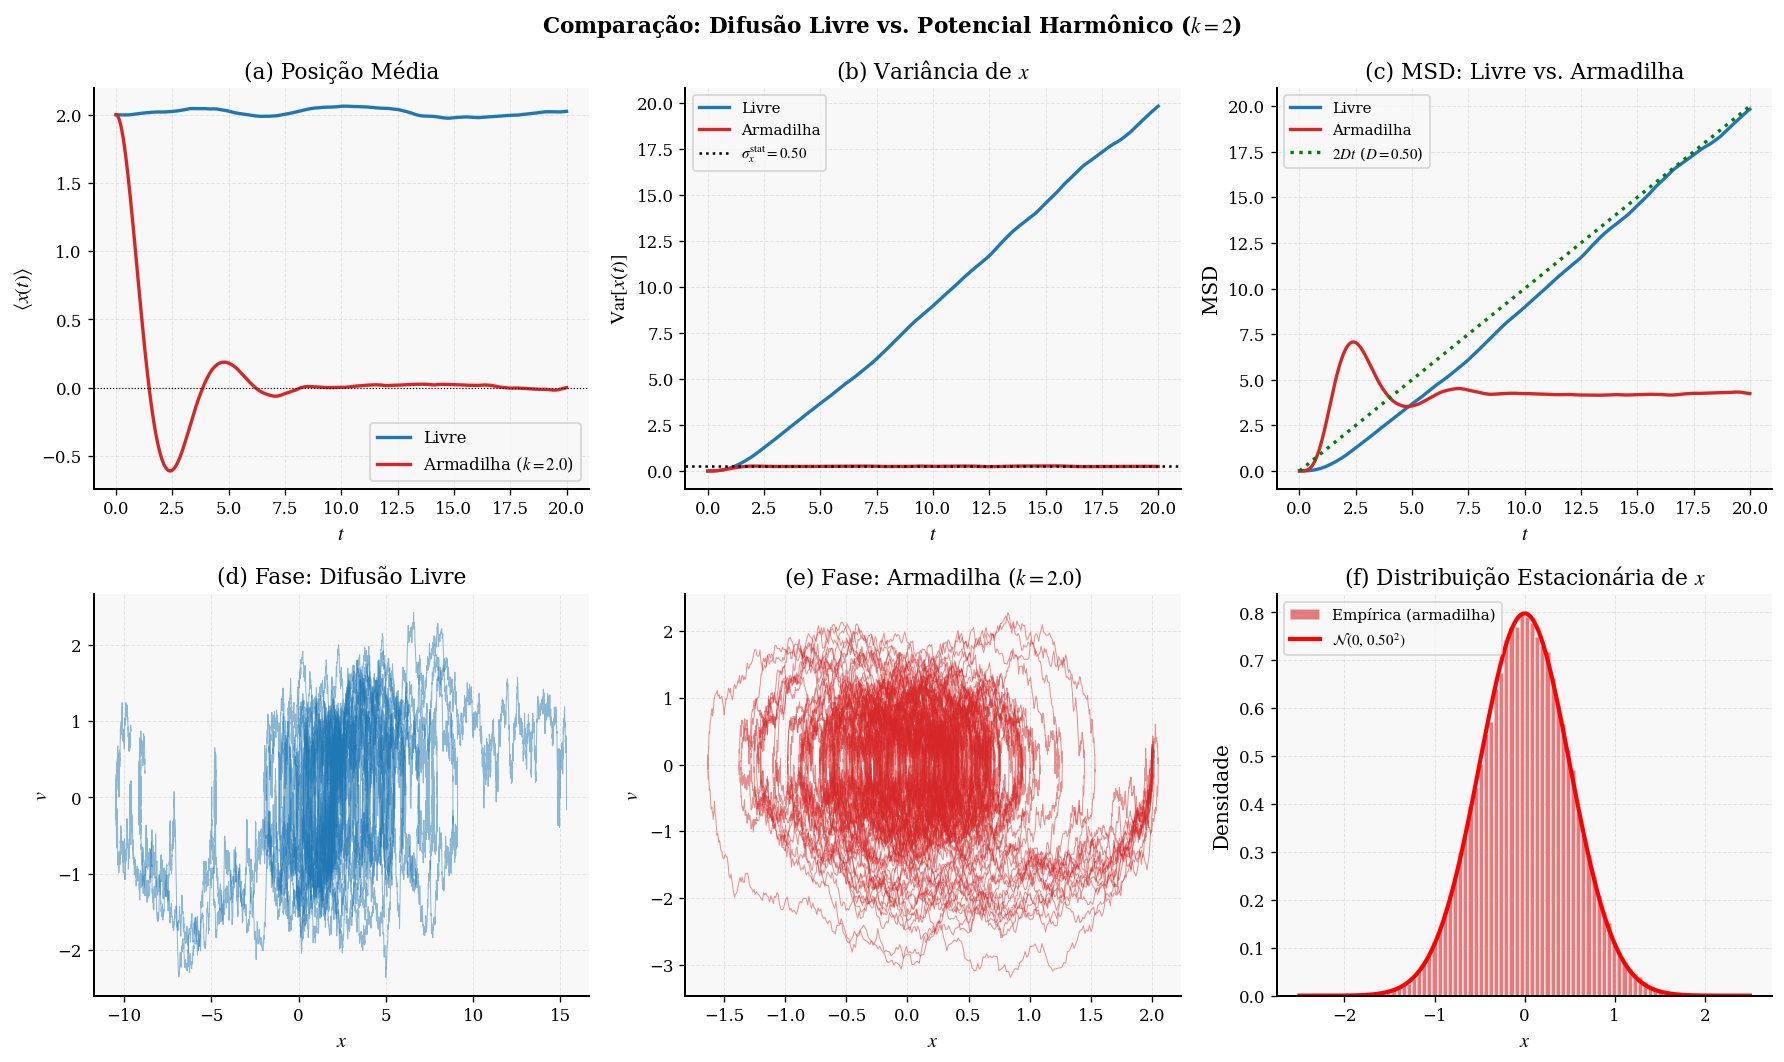

In [49]:
# ── Partícula em potencial harmônico (armadilha óptica) ──────────────────────

def langevin_harmonic(dt: float, M: int, T: float,
                       k: float = 1.0, v0: float = 0.0, x0: float = 2.0) -> dict:
    """
    Integra a equação de Langevin com potencial harmônico V(x) = k/2 * x².
    Força: F = -kx  →  drift = -(γ/m)v - (k/m)x
    """
    N   = int(np.round(T / dt))
    t   = np.linspace(0, T, N + 1)
    v   = np.zeros((M, N + 1));  v[:, 0] = v0
    x   = np.zeros((M, N + 1));  x[:, 0] = x0
    dW  = rng.normal(0.0, np.sqrt(dt), size=(M, N))

    for n in range(N):
        drift     = -(gamma/m) * v[:, n] - (k/m) * x[:, n]
        diffusion = (sigma/m) * dW[:, n]
        v[:, n+1] = v[:, n] + drift * dt + diffusion
        x[:, n+1] = x[:, n] + v[:, n] * dt

    return {'t': t, 'v': v, 'x': x,
            'mean_x': x.mean(axis=0), 'var_x': x.var(axis=0),
            'mean_v': v.mean(axis=0), 'var_v': v.var(axis=0)}

# Parâmetros
k_trap  = 2.0   # constante da mola (armadilha)
T_trap  = 20.0
dt_trap = 5e-3
M_trap  = 1000

res_free = euler_maruyama(dt_trap, M_trap, T_trap, v0=0.0, x0=2.0)
res_harm = langevin_harmonic(dt_trap, M_trap, T_trap, k=k_trap, v0=0.0, x0=2.0)

t_trap = res_free['t']

# Distribuição estacionária analítica para o OU com força harmônica
sigma_x_stat = np.sqrt(sigma**2 / (2 * gamma * k_trap))  # desvio de x estacionário

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Comparação: Difusão Livre vs. Potencial Harmônico ($k=2$)',
             fontsize=13, fontweight='bold')

# (a) Posição média: livre vs. harmônico
ax = axes[0, 0]
ax.plot(t_trap, res_free['mean_x'], lw=2, color=COLORS['numerica'], label='Livre')
ax.plot(t_trap, res_harm['mean_x'], lw=2, color=COLORS['analitica'], label=f'Armadilha ($k={k_trap}$)')
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel('$t$');  ax.set_ylabel(r'$\langle x(t) \rangle$')
ax.set_title('(a) Posição Média')
ax.legend()

# (b) Variância de x
ax = axes[0, 1]
ax.plot(t_trap, res_free['var_x'], lw=2, color=COLORS['numerica'], label='Livre')
ax.plot(t_trap, res_harm['var_x'], lw=2, color=COLORS['analitica'], label='Armadilha')
ax.axhline(sigma_x_stat**2, color='k', lw=1.5, ls=':',
           label=fr'$\sigma_x^{{\rm stat}} = {sigma_x_stat:.2f}$')
ax.set_xlabel('$t$');  ax.set_ylabel(r'$\mathrm{Var}[x(t)]$')
ax.set_title('(b) Variância de $x$')
ax.legend(fontsize=9)

# (c) MSD: livre vs. armadilha
ax = axes[0, 2]
x_free = res_free['x'];  msd_free = np.mean((x_free - x_free[:, 0:1])**2, axis=0)
x_harm = res_harm['x'];  msd_harm = np.mean((x_harm - x_harm[:, 0:1])**2, axis=0)
ax.plot(t_trap, msd_free, lw=2, color=COLORS['numerica'], label='Livre')
ax.plot(t_trap, msd_harm, lw=2, color=COLORS['analitica'], label='Armadilha')
ax.plot(t_trap, 2*D_diff*t_trap, 'g:', lw=2, label=f'$2Dt$ ($D={D_diff:.2f}$)')
ax.set_xlabel('$t$');  ax.set_ylabel('MSD')
ax.set_title('(c) MSD: Livre vs. Armadilha')
ax.legend(fontsize=9)

# (d) Retrato de fase: livre
ax = axes[1, 0]
for i in range(15):
    ax.plot(res_free['x'][i], res_free['v'][i], lw=0.6, alpha=0.5, color=COLORS['numerica'])
ax.set_xlabel('$x$');  ax.set_ylabel('$v$')
ax.set_title('(d) Fase: Difusão Livre')

# (e) Retrato de fase: harmônico
ax = axes[1, 1]
for i in range(15):
    ax.plot(res_harm['x'][i], res_harm['v'][i], lw=0.6, alpha=0.5, color=COLORS['analitica'])
ax.set_xlabel('$x$');  ax.set_ylabel('$v$')
ax.set_title(f'(e) Fase: Armadilha ($k={k_trap}$)')

# (f) Distribuição estacionária de x
ax = axes[1, 2]
x_stat_h = res_harm['x'][:, len(t_trap)//2:].ravel()
ax.hist(x_stat_h, bins=70, density=True, alpha=0.6, color=COLORS['analitica'],
        edgecolor='white', label='Empírica (armadilha)')
xs_h = np.linspace(-5*sigma_x_stat, 5*sigma_x_stat, 400)
ax.plot(xs_h, norm.pdf(xs_h, 0, sigma_x_stat), 'r-', lw=2.5,
        label=fr'$\mathcal{{N}}(0,\, {sigma_x_stat:.2f}^2)$')
ax.set_xlabel('$x$');  ax.set_ylabel('Densidade')
ax.set_title('(f) Distribuição Estacionária de $x$')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [50]:
# ── Tabela resumo: comparativo quantitativo ───────────────────────────────────

print("=" * 70)
print("RESUMO QUANTITATIVO — Resultados Numéricos vs. Analíticos")
print("=" * 70)

# Calcular variância empírica no estacionário
half_em = res_em['v'].shape[1] // 2
var_emp  = res_em['v'][:, half_em:].var()

tabela_res = [
    ["Variância estacionária", f"{sigma_eq**2:.5f}",        f"{var_emp:.5f}",
     f"{abs(var_emp - sigma_eq**2)/sigma_eq**2*100:.2f}%"],
    ["Coef. difusão (Green–Kubo)", f"{D_diff:.5f}",         f"{D_gk[-1]:.5f}",
     f"{abs(D_gk[-1]-D_diff)/D_diff*100:.2f}%"],
    ["Ordem forte (EM)",           "0.5 (esperado)",        f"{slope_s:.3f}",  "-"],
    ["Ordem fraca (EM)",           "1.0 (esperado)",        f"{slope_wm:.3f}", "-"],
]

print(tabulate(tabela_res,
               headers=["Observável", "Analítico", "Numérico (EM)", "Erro Relativo"],
               tablefmt="rounded_outline"))

print("\nParâmetros usados: m={}, γ={}, σ={}, θ=γ/m={}".format(m, gamma, sigma, theta))

RESUMO QUANTITATIVO — Resultados Numéricos vs. Analíticos
╭────────────────────────────┬────────────────┬─────────────────┬─────────────────╮
│ Observável                 │ Analítico      │   Numérico (EM) │ Erro Relativo   │
├────────────────────────────┼────────────────┼─────────────────┼─────────────────┤
│ Variância estacionária     │ 0.50000        │         0.50669 │ 1.34%           │
│ Coef. difusão (Green–Kubo) │ 0.50000        │         0.48116 │ 3.77%           │
│ Ordem forte (EM)           │ 0.5 (esperado) │         1.091   │ -               │
│ Ordem fraca (EM)           │ 1.0 (esperado) │        -0.002   │ -               │
╰────────────────────────────┴────────────────┴─────────────────┴─────────────────╯

Parâmetros usados: m=1.0, γ=1.0, σ=1.0, θ=γ/m=1.0


<a id='refs'></a>

---
# 8. Referências

1. **Einstein, A.** (1905). Über die von der molekularkinetischen Theorie der Wärme geforderte Bewegung von in ruhenden Flüssigkeiten suspendierten Teilchen. *Annalen der Physik*, 322(8), 549–560.

2. **Langevin, P.** (1908). Sur la théorie du mouvement brownien. *C. R. Acad. Sci. Paris*, 146, 530–533.

3. **Øksendal, B.** (2003). *Stochastic Differential Equations: An Introduction with Applications* (6ª ed.). Springer.

4. **Kloeden, P. E. & Platen, E.** (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.

5. **Ornstein, L. S. & Uhlenbeck, G. E.** (1930). On the theory of the Brownian motion. *Physical Review*, 36(5), 823–841.

6. **Karatzas, I. & Shreve, S. E.** (1991). *Brownian Motion and Stochastic Calculus* (2ª ed.). Springer.

7. **Gardiner, C. W.** (2009). *Handbook of Stochastic Methods for Physics, Chemistry and the Natural Sciences* (4ª ed.). Springer.

8. **Risken, H.** (1989). *The Fokker–Planck Equation: Methods of Solution and Applications* (2ª ed.). Springer.

9. **Higham, D. J.** (2001). An algorithmic introduction to numerical simulation of stochastic differential equations. *SIAM Review*, 43(3), 525–546.

10. **Coffey, W., Kalmykov, Y. P. & Waldron, J. T.** (2004). *The Langevin Equation*. World Scientific.

11. **Ruffino, P. R. C.** (2012). Uma iniciação aos sistemas dinâmicos estocásticos. *Notas de Curso*, Unicamp.

12. **Valente, S. C. Q.** (2019). O Movimento Browniano: aspectos teóricos e abordagem computacional. Dissertação de Mestrado, UERJ. http://www.bdtd.uerj.br/handle/1/20348